In [1]:
import mne
# from mne.io import read_raw
import numpy as np
# import matplotlib.pyplot as plt
from os.path import join
import os
# import pandas as pd
import json
# from collections import defaultdict

from functions import ephy_plotting, utils, analysis, ephy_meta_function

# 1. Load the dataset #

In [2]:
working_path = os.path.dirname(os.getcwd())
results_path = join(working_path, "results")
behav_results_saving_path = join(results_path, "behav_results")
onedrive_path = utils._get_onedrive_path()

#  Set saving path
filtered_epochs = False
if filtered_epochs:
    filt = [None, 40]  # Frequency range for filtering
    freq_wide = f'{filt[0]}-{filt[1]}Hz'
    fmin = filt[0]
    fmax = filt[1]
else:
    freq_wide = 'all frequencies'
    fmin = 1
    fmax = 80

#freq_wide = f'{40}-{80}Hz'
saving_path_group = join(results_path, 'group_level', 'lfp_erp_sig_change', freq_wide)  
os.makedirs(saving_path_group, exist_ok=True)  # Create the directory if it doesn't exist
saving_path_on_off = join(results_path, 'ON_vs_OFF', 'erp', freq_wide)
os.makedirs(saving_path_on_off, exist_ok=True)

epochs_path = epochs_path = "D:\\Juliette\\data mSST\\lfp_epochs"

# load threshold_jc dictionary from json file
threshold_file = join(results_path, 'gc_thresholds.json')
with open(threshold_file, 'r') as f:
    threshold_gc_dict = json.load(f)

# read the json file containing the included and excluded subjects, based on the behavioral results
included_excluded_file = join(results_path, 'final_included_subjects.json')
with open(included_excluded_file, 'r') as file:
    included_subjects = json.load(file)

# included_subjects.remove('sub032 DBS OFF mSST')  # remove this subject due to too many artifacts
# included_subjects.remove('sub032 DBS ON mSST')  # remove this subject due to too many artifacts
included_subjects.remove('sub029 DBS OFF mSST')  # remove this subject due to too many artifacts
included_subjects.remove('sub029 DBS ON mSST')  # remove this subject due to too many artifacts
# included_subjects.remove('sub023 DBS OFF mSST')  # remove this subject due to too many artifacts
# included_subjects.remove('sub023 DBS ON mSST')  # remove this subject due to too many artifacts
# included_subjects.remove('sub028 DBS ON mSST')  # remove this subject for erp
# included_subjects.remove('sub033 DBS OFF mSST')  # remove this subject for erp
# included_subjects.remove('sub033 DBS ON mSST')  # remove this subject for erp
# included_subjects.remove('sub019 DBS OFF mSST')  # remove this subject for gamma analysis
# included_subjects.remove('sub019 DBS ON mSST')  # remove this subject for gamma analysis
# included_subjects.remove('sub025 DBS OFF mSST')  # remove this subject for gamma analysis
# included_subjects.remove('sub025 DBS ON mSST') # remove this subject for gamma analysis
# included_subjects.remove('sub032 DBS OFF mSST')  # remove this subject for gamma analysis
# included_subjects.remove('sub032 DBS ON mSST') # remove this subject for gamma analysis

# keep only subjects starting with "sub":X
included_subjects = [subj for subj in included_subjects if subj.startswith('sub')]
print(f'Included_subjects: {included_subjects}')


Included_subjects: ['sub006 DBS ON mSST', 'sub006 DBS OFF mSST', 'sub011 DBS OFF mSST', 'sub011 DBS ON mSST', 'sub012 DBS ON mSST', 'sub012 DBS OFF mSST', 'sub015 DBS OFF mSST', 'sub015 DBS ON mSST', 'sub019 DBS ON mSST', 'sub019 DBS OFF mSST', 'sub023 DBS OFF mSST', 'sub023 DBS ON mSST', 'sub025 DBS ON mSST', 'sub025 DBS OFF mSST', 'sub027 DBS ON mSST', 'sub027 DBS OFF mSST', 'sub028 DBS OFF mSST', 'sub028 DBS ON mSST', 'sub032 DBS ON mSST', 'sub032 DBS OFF mSST', 'sub033 DBS ON mSST', 'sub033 DBS OFF mSST']


In [3]:
sub_dict_epochs = {}

for session_ID in included_subjects:
    epochs = mne.read_epochs(
        os.path.join(epochs_path, 
        session_ID.split(' ')[0],
        ('DBS ' + session_ID.split(' ')[2]),
        f"{session_ID}_cleaned-long-epo.fif"
        ), 
        preload=True)
    # resample to 250Hz
    epochs.resample(250, npad="auto")
    sub_dict_epochs[session_ID] = epochs
    

Reading D:\Juliette\data mSST\lfp_epochs\sub006\DBS ON\sub006 DBS ON mSST_cleaned-long-epo.fif ...
Isotrak not found
    Found the data of interest:
        t =   -3499.98 ...    3499.98 ms
        0 CTF compensation matrices available
Adding metadata with 15 columns
623 matching events found
No baseline correction applied
0 projection items activated
Reading D:\Juliette\data mSST\lfp_epochs\sub006\DBS OFF\sub006 DBS OFF mSST_cleaned-long-epo.fif ...
Isotrak not found
    Found the data of interest:
        t =   -3500.22 ...    3500.22 ms
        0 CTF compensation matrices available
Adding metadata with 20 columns
454 matching events found
No baseline correction applied
0 projection items activated
Reading D:\Juliette\data mSST\lfp_epochs\sub011\DBS OFF\sub011 DBS OFF mSST_cleaned-long-epo.fif ...
Isotrak not found
    Found the data of interest:
        t =   -3500.12 ...    3500.12 ms
        0 CTF compensation matrices available
Adding metadata with 16 columns
628 matching events 

# 2. ERP analysis group level, intra group (only DBS ON or only DBS OFF) #

In [4]:
condition_color_dict = {
    'GO_successful': 'black', 
    'GF_successful': 'green', 
    'GS_successful': 'orange', 
    'GS_unsuccessful': 'red', 
    'GC_successful': 'blue',
    'lmGO_successful': 'darkgreen'
    }

color_dict = {
    'DBS ON': '#20a39e', 
    'DBS OFF': '#ef5b5b'}

## 2.1. Proactive inhibition ##

Comparison GO trials versus GF trials

Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)

Number of subjects included: 11
Subjects: ['sub006 DBS ON mSST', 'sub011 DB

  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

Using a threshold of 2.228139
stat_fun(H1): min=-4.156925343459924 max=6.834414616567664
Running initial clustering …
Found 18 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

Significant cluster | Right_STN | p = 0.0030 | 0.780–0.912 s


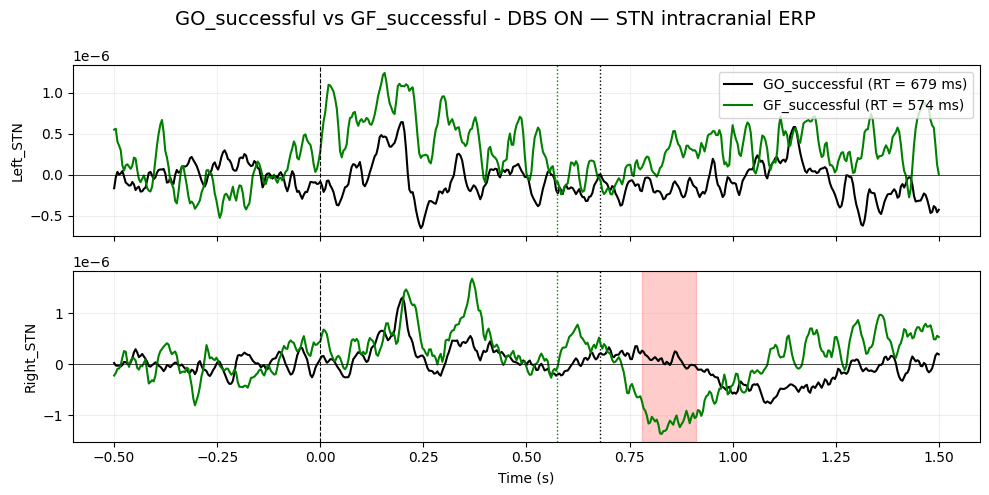

Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)

Number of subjects included: 11
Subjects: ['sub006 DBS OFF mSST', 'sub011 D

  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

Using a threshold of 2.228139
stat_fun(H1): min=-5.193348096448346 max=4.146184255969933
Running initial clustering …
Found 12 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

Significant cluster | Right_STN | p = 0.0130 | 0.748–0.812 s


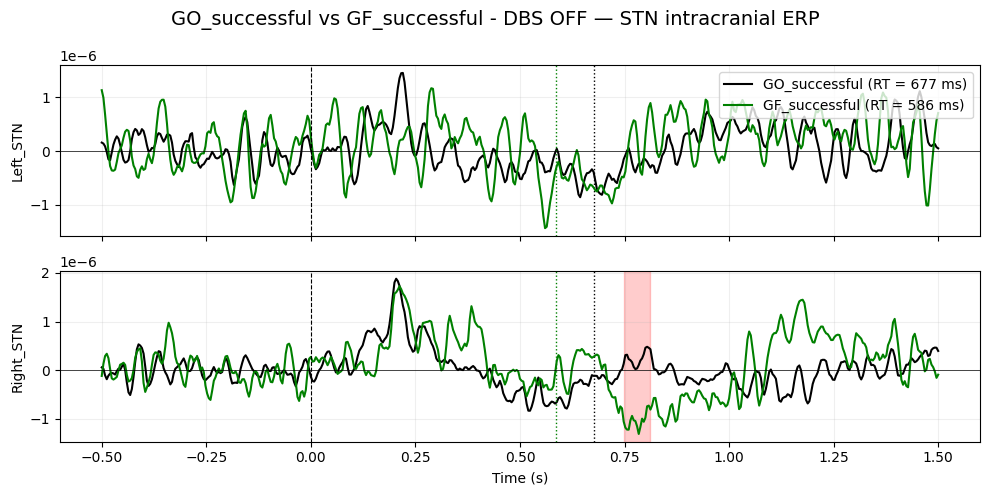

In [5]:
temp_save = os.path.join(saving_path_group, 'proactive inhibition')
if not os.path.exists(temp_save):
    os.makedirs(temp_save)

epoch_cond1 = 'GO_successful'
epoch_cond2 = 'GF_successful'

for dbs_status in ['DBS ON', 'DBS OFF']:
    condition = f'{epoch_cond1} vs {epoch_cond2} - {dbs_status}'
    avg_cond1, avg_cond2, cluster_results, subs_included = ephy_meta_function.stn_erp_change_diff_cond(
        sub_dict_epochs=sub_dict_epochs,
        dbs_status=dbs_status,
        epoch_cond1=epoch_cond1,
        epoch_cond2=epoch_cond2,
        condition=condition,
        condition_color_dict=condition_color_dict,
        alpha=0.05,
        n_permutations=1000,
        save_as = 'png',
        saving_path = temp_save
    )

## 2.2. Reactive inhibition ##

Comparison GS (successful) trials with GO trials.


Comparison GS (successful) trials with lmGO trials.


Comparison GS (successful) with GS (unsuccessful) trials.

Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)

Number of subjects included: 11
Subjects: ['sub006 DBS ON mSST', 'sub011 DB

c:\Users\Juliette\Research\Projects\analysis_mSST\scripts\functions\ephy_meta_function.py:1370: RuntimeWarning: Mean of empty slice
  mean_rt_cond2 = np.nanmean(


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

Using a threshold of 2.228139
stat_fun(H1): min=-3.871936702561398 max=2.050251509205621
Running initial clustering …
Found 1 cluster


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

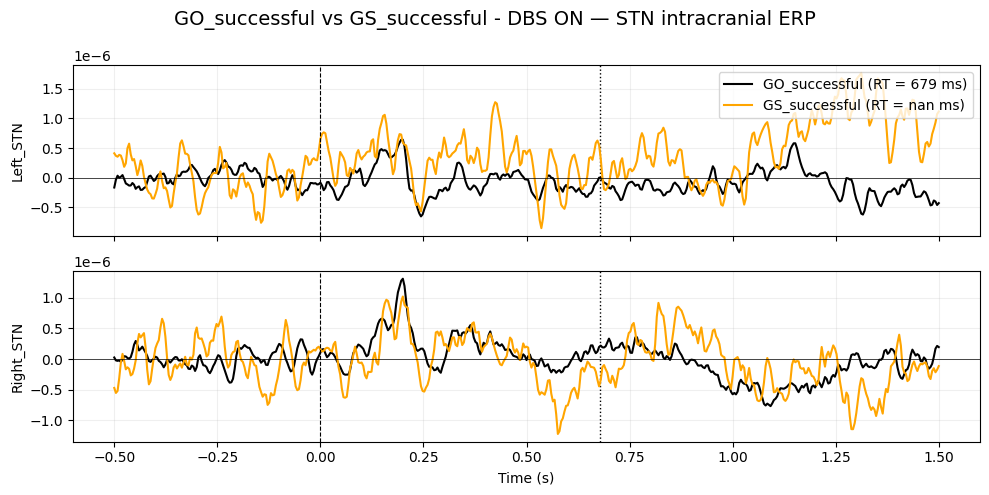

Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)

Number of subjects included: 11
Subjects: ['sub006 DBS OFF mSST', 'sub011 D

c:\Users\Juliette\Research\Projects\analysis_mSST\scripts\functions\ephy_meta_function.py:1370: RuntimeWarning: Mean of empty slice
  mean_rt_cond2 = np.nanmean(


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

Using a threshold of 2.228139
stat_fun(H1): min=-2.6739786124918026 max=2.7779626583608543
Running initial clustering …
Found 8 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

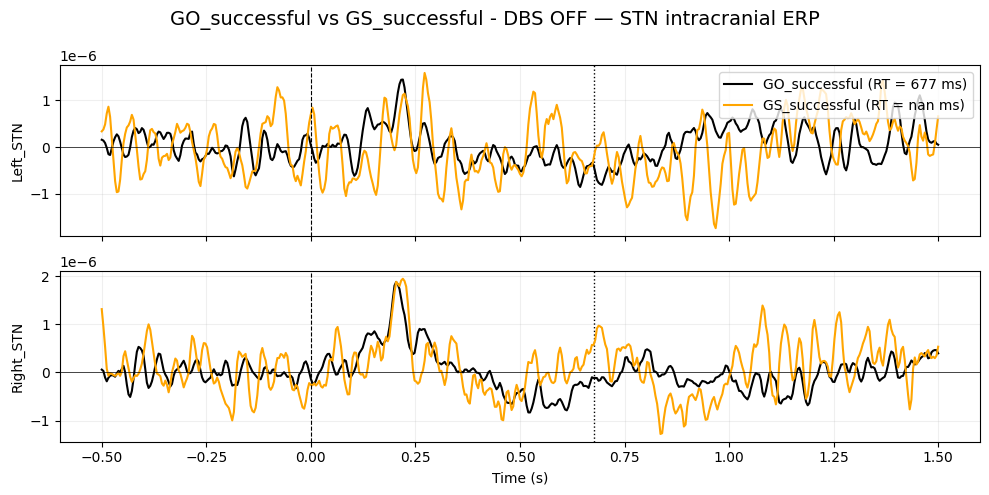

In [7]:
temp_save = os.path.join(saving_path_group, 'reactive inhibition', 'using GO')
if not os.path.exists(temp_save):
    os.makedirs(temp_save)

epoch_cond1 = 'GO_successful'
epoch_cond2 = 'GS_successful'

for dbs_status in ['DBS ON', 'DBS OFF']:
    condition = f'{epoch_cond1} vs {epoch_cond2} - {dbs_status}'
    avg_cond1, avg_cond2, cluster_results, subs_included = ephy_meta_function.stn_erp_change_diff_cond(
        sub_dict_epochs=sub_dict_epochs,
        dbs_status=dbs_status,
        epoch_cond1=epoch_cond1,
        epoch_cond2=epoch_cond2,
        condition=condition,
        condition_color_dict=condition_color_dict,
        alpha=0.05,
        n_permutations=1000,
        save_as = 'png',
        saving_path = temp_save
    )

Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)

Number of subjects included: 11
Subjects: ['sub006 DBS ON mSST', 'sub011 DB

c:\Users\Juliette\Research\Projects\analysis_mSST\scripts\functions\ephy_meta_function.py:1370: RuntimeWarning: Mean of empty slice
  mean_rt_cond2 = np.nanmean(


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

Using a threshold of 2.228139
stat_fun(H1): min=-3.990799154684825 max=2.2562942133486157
Running initial clustering …
Found 6 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

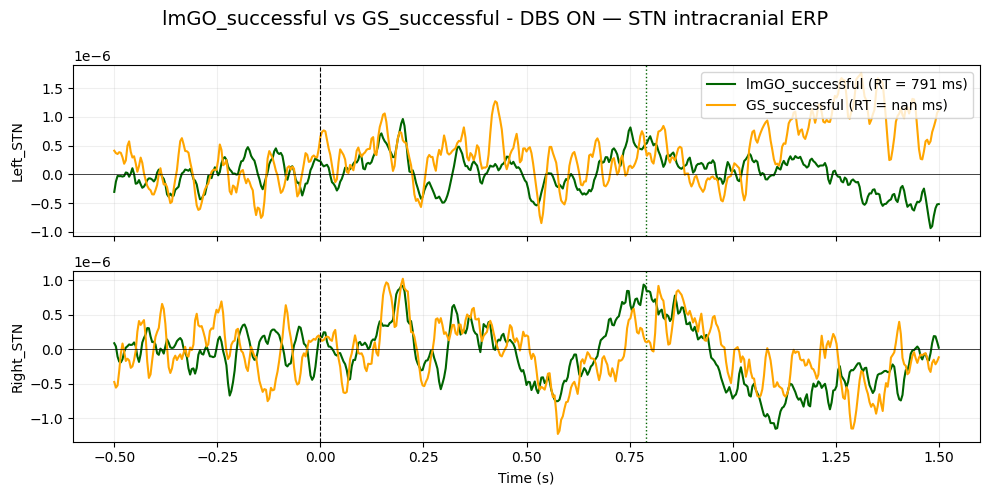

Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)

Number of subjects included: 11
Subjects: ['sub006 DBS OFF mSST', 'sub011 D

c:\Users\Juliette\Research\Projects\analysis_mSST\scripts\functions\ephy_meta_function.py:1370: RuntimeWarning: Mean of empty slice
  mean_rt_cond2 = np.nanmean(


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

Using a threshold of 2.228139
stat_fun(H1): min=-3.6593699693288624 max=2.6152384931180097
Running initial clustering …
Found 14 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

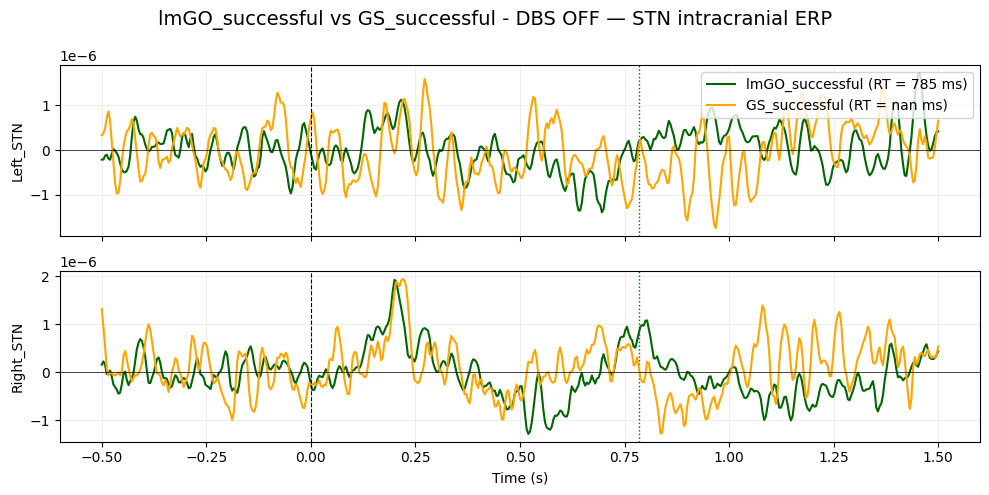

In [8]:
temp_save = os.path.join(saving_path_group, 'reactive inhibition', 'using lmGO')
if not os.path.exists(temp_save):
    os.makedirs(temp_save)

epoch_cond1 = 'lmGO_successful' 
epoch_cond2 = 'GS_successful'

for dbs_status in ['DBS ON', 'DBS OFF']:
    condition = f'{epoch_cond1} vs {epoch_cond2} - {dbs_status}'
    avg_cond1, avg_cond2, cluster_results, subs_included = ephy_meta_function.stn_erp_change_diff_cond(
        sub_dict_epochs=sub_dict_epochs,
        dbs_status=dbs_status,
        epoch_cond1=epoch_cond1,
        epoch_cond2=epoch_cond2,
        condition=condition,
        condition_color_dict=condition_color_dict,
        alpha=0.05,
        n_permutations=1000,
        save_as = 'png',
        saving_path = temp_save
    )

Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)

Number of subjects included: 11
Subjects: ['sub006 DBS ON mSST', 'sub011 DB

c:\Users\Juliette\Research\Projects\analysis_mSST\scripts\functions\ephy_meta_function.py:1366: RuntimeWarning: Mean of empty slice
  mean_rt_cond1 = np.nanmean(


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

Using a threshold of 2.228139
stat_fun(H1): min=-2.203703082956281 max=2.922595244170036
Running initial clustering …
Found 7 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

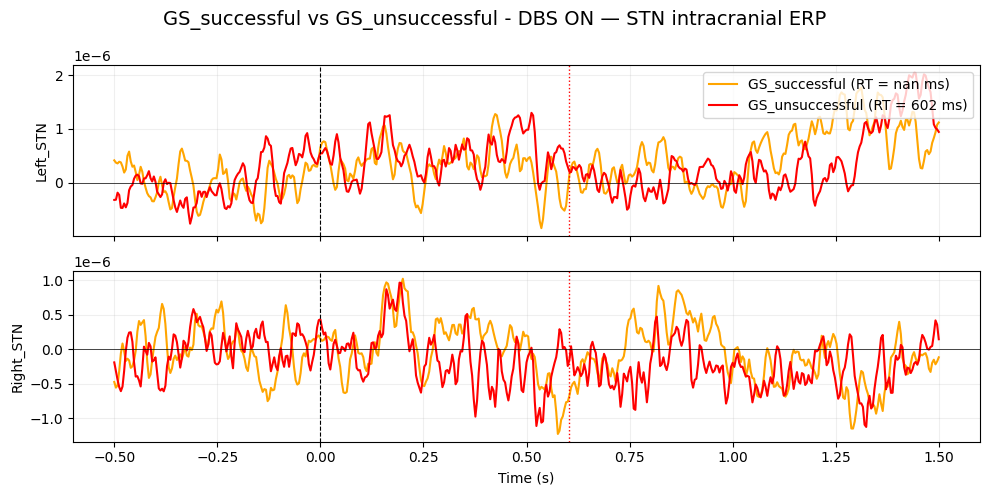

Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)

Number of subjects included: 11
Subjects: ['sub006 DBS OFF mSST', 'sub011 D

c:\Users\Juliette\Research\Projects\analysis_mSST\scripts\functions\ephy_meta_function.py:1366: RuntimeWarning: Mean of empty slice
  mean_rt_cond1 = np.nanmean(


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

Using a threshold of 2.228139
stat_fun(H1): min=-3.868947191337434 max=2.373242556417317
Running initial clustering …
Found 6 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

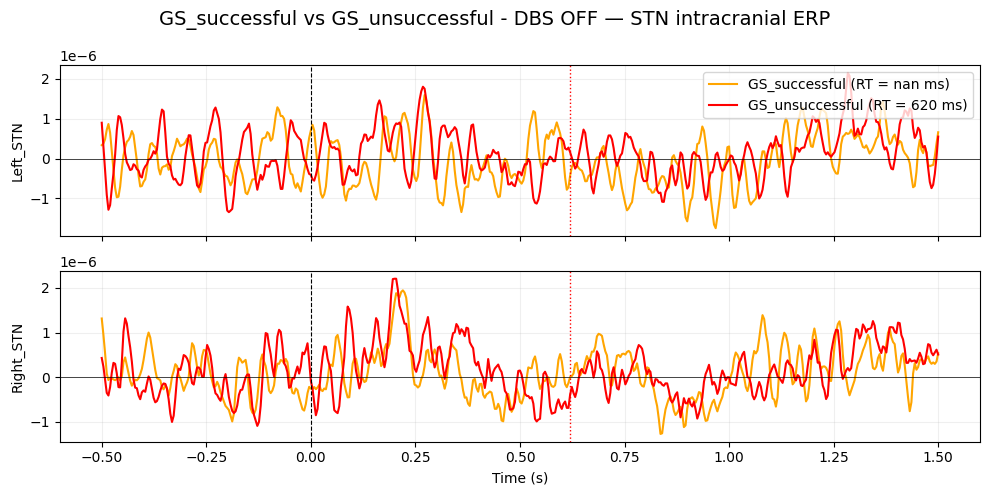

In [9]:
temp_save = os.path.join(saving_path_group, 'reactive inhibition', 'using GS only')
if not os.path.exists(temp_save):
    os.makedirs(temp_save)

epoch_cond1 = 'GS_successful'
epoch_cond2 = 'GS_unsuccessful'

for dbs_status in ['DBS ON', 'DBS OFF']:
    condition = f'{epoch_cond1} vs {epoch_cond2} - {dbs_status}'
    avg_cond1, avg_cond2, cluster_results, subs_included = ephy_meta_function.stn_erp_change_diff_cond(
        sub_dict_epochs=sub_dict_epochs,
        dbs_status=dbs_status,
        epoch_cond1=epoch_cond1,
        epoch_cond2=epoch_cond2,
        condition=condition,
        condition_color_dict=condition_color_dict,
        alpha=0.05,
        n_permutations=1000,
        save_as = 'png',
        saving_path = temp_save
    )

Tests other contrasts

Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)

Number of subjects included: 11
Subjects: ['sub006 DBS ON mSST', 'sub011 DB

  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

Using a threshold of 2.228139
stat_fun(H1): min=-4.559025041079803 max=2.781218158476606
Running initial clustering …
Found 13 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

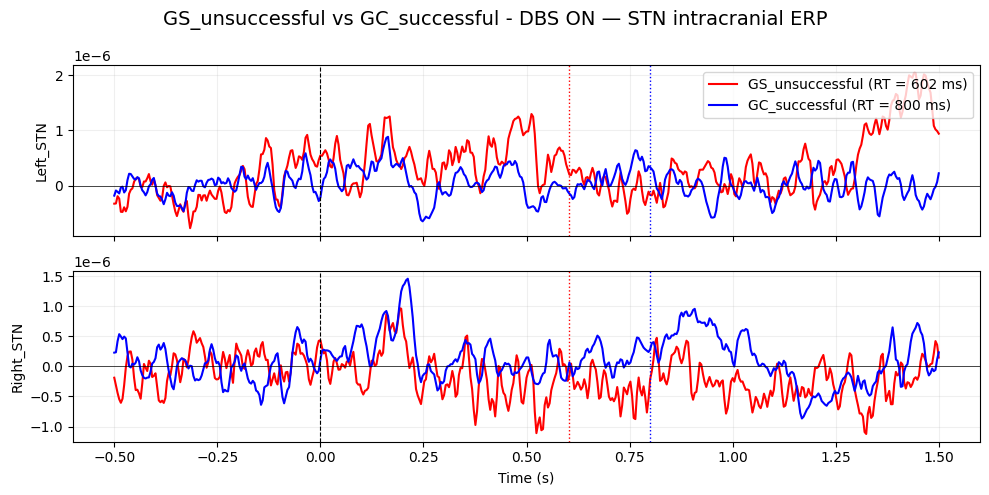

Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)

Number of subjects included: 11
Subjects: ['sub006 DBS OFF mSST', 'sub011 D

  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

Using a threshold of 2.228139
stat_fun(H1): min=-3.950854845030862 max=3.8825701352389976
Running initial clustering …
Found 11 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

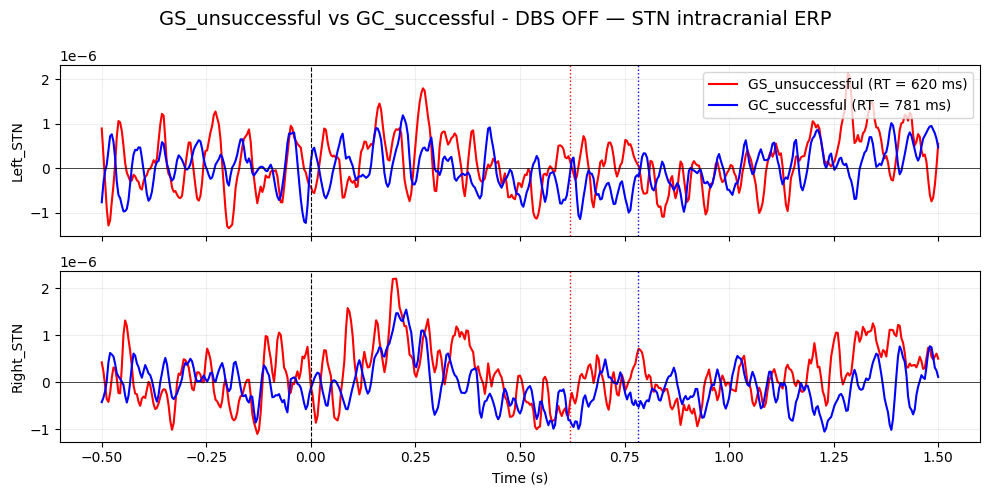

In [10]:
temp_save = os.path.join(saving_path_group, 'holder')
if not os.path.exists(temp_save):
    os.makedirs(temp_save)

epoch_cond1 = 'GS_unsuccessful' 
epoch_cond2 = 'GC_successful'

for dbs_status in ['DBS ON', 'DBS OFF']:
    condition = f'{epoch_cond1} vs {epoch_cond2} - {dbs_status}'
    avg_cond1, avg_cond2, cluster_results, subs_included = ephy_meta_function.stn_erp_change_diff_cond(
        sub_dict_epochs=sub_dict_epochs,
        dbs_status=dbs_status,
        epoch_cond1=epoch_cond1,
        epoch_cond2=epoch_cond2,
        condition=condition,
        condition_color_dict=condition_color_dict,
        alpha=0.05,
        n_permutations=1000,
        save_as = 'png',
        saving_path = temp_save
    )

# 3. TFR analysis group level, inter groups (DBS ON versus DBS OFF) #

Applying baseline correction (mode: mean)


Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)

Number of paired subjects included: 11
Subjects: ['sub006  mSST', 'sub011  mSST', 'sub012  mSST', 'sub015  mSST', 'su

  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

Using a threshold of 2.228139
stat_fun(H1): min=-2.252316573458054 max=4.219282927095494
Running initial clustering …
Found 4 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

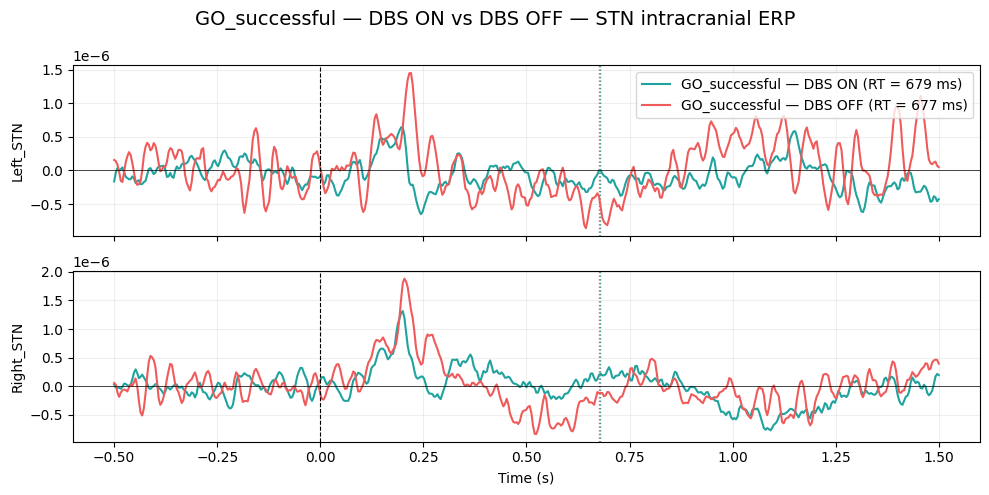

In [11]:
temp_save = os.path.join(saving_path_on_off, 'GO')
if not os.path.exists(temp_save):
    os.makedirs(temp_save)

epoch_cond = 'GO_successful'

avg_on, avg_off, cluster_results, subjects_included, mean_rt_on, mean_rt_off, rt_by_subject = ephy_meta_function.stn_erp_change_diff_on_off(
    sub_dict_epochs=sub_dict_epochs,
    epoch_cond=epoch_cond,
    condition_color_dict=color_dict,
    saving_path=temp_save,
    alpha=0.05,
    n_permutations=1000,
    save_as='png'
)

Applying baseline correction (mode: mean)


Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)

Number of paired subjects included: 11
Subjects: ['sub006  mSST', 'sub011  mSST', 'sub012  mSST', 'sub015  mSST', 'su

  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

Using a threshold of 2.228139
stat_fun(H1): min=-4.393314166146415 max=2.971482288735639
Running initial clustering …
Found 9 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

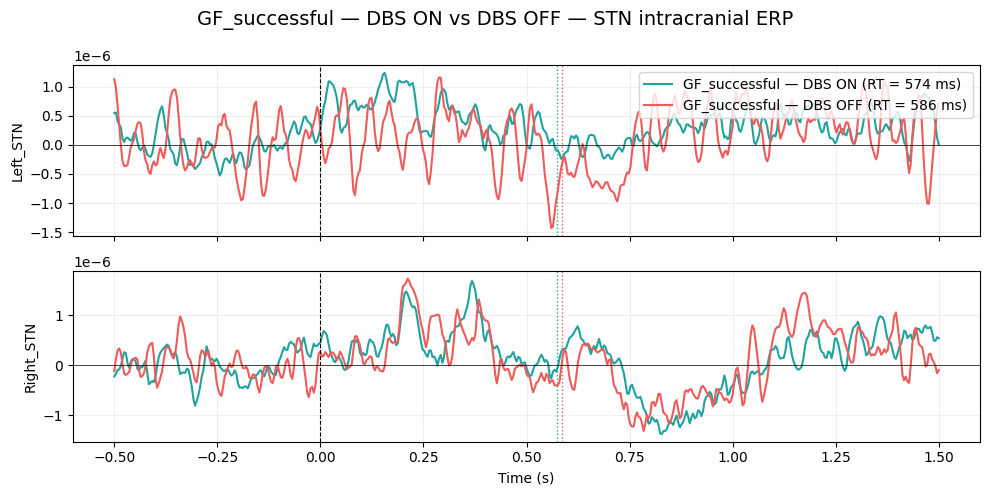

In [12]:
temp_save = os.path.join(saving_path_on_off, 'GF')
if not os.path.exists(temp_save):
    os.makedirs(temp_save)

epoch_cond = 'GF_successful'

avg_on, avg_off, cluster_results, subjects_included, mean_rt_on, mean_rt_off, rt_by_subject = ephy_meta_function.stn_erp_change_diff_on_off(
    sub_dict_epochs=sub_dict_epochs,
    epoch_cond=epoch_cond,
    condition_color_dict=color_dict,
    saving_path=temp_save,
    alpha=0.05,
    n_permutations=1000,
    save_as='png'
)

Applying baseline correction (mode: mean)


Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)

Number of paired subjects included: 11
Subjects: ['sub006  mSST', 'sub011  mSST', 'sub012  mSST', 'sub015  mSST', 'su

c:\Users\Juliette\Research\Projects\analysis_mSST\scripts\functions\ephy_meta_function.py:2026: RuntimeWarning: Mean of empty slice
  mean_rt_on = np.nanmean([
c:\Users\Juliette\Research\Projects\analysis_mSST\scripts\functions\ephy_meta_function.py:2031: RuntimeWarning: Mean of empty slice
  mean_rt_off = np.nanmean([


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

Using a threshold of 2.228139
stat_fun(H1): min=-3.6475428121900584 max=3.2624939551160463
Running initial clustering …
Found 14 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

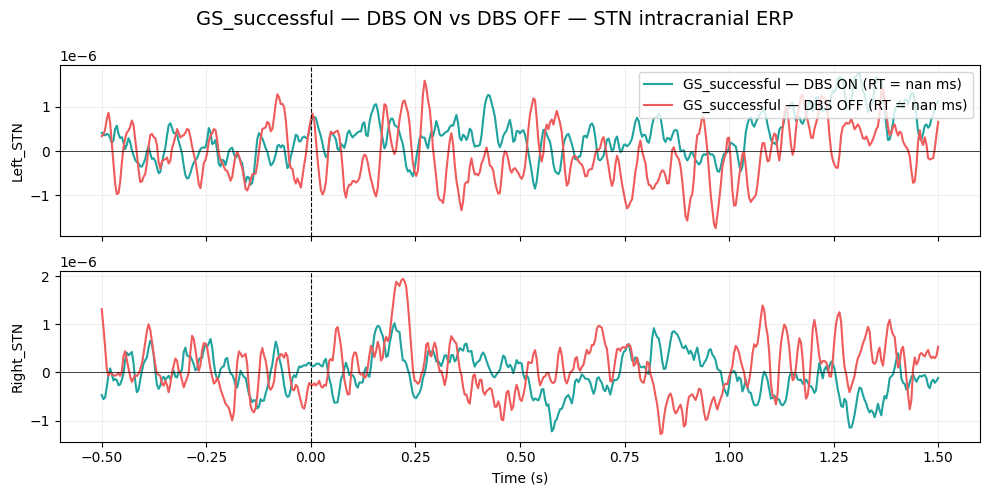

In [13]:
temp_save = os.path.join(saving_path_on_off, 'GS')
if not os.path.exists(temp_save):
    os.makedirs(temp_save)

epoch_cond = 'GS_successful'

avg_on, avg_off, cluster_results, subjects_included, mean_rt_on, mean_rt_off, rt_by_subject = ephy_meta_function.stn_erp_change_diff_on_off(
    sub_dict_epochs=sub_dict_epochs,
    epoch_cond=epoch_cond,
    condition_color_dict=color_dict,
    saving_path=temp_save,
    alpha=0.05,
    n_permutations=1000,
    save_as='png'
)

Applying baseline correction (mode: mean)


Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)

Number of paired subjects included: 11
Subjects: ['sub006  mSST', 'sub011  mSST', 'sub012  mSST', 'sub015  mSST', 'su

  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

Using a threshold of 2.228139
stat_fun(H1): min=-3.1521610732447543 max=2.412072687268654
Running initial clustering …
Found 17 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

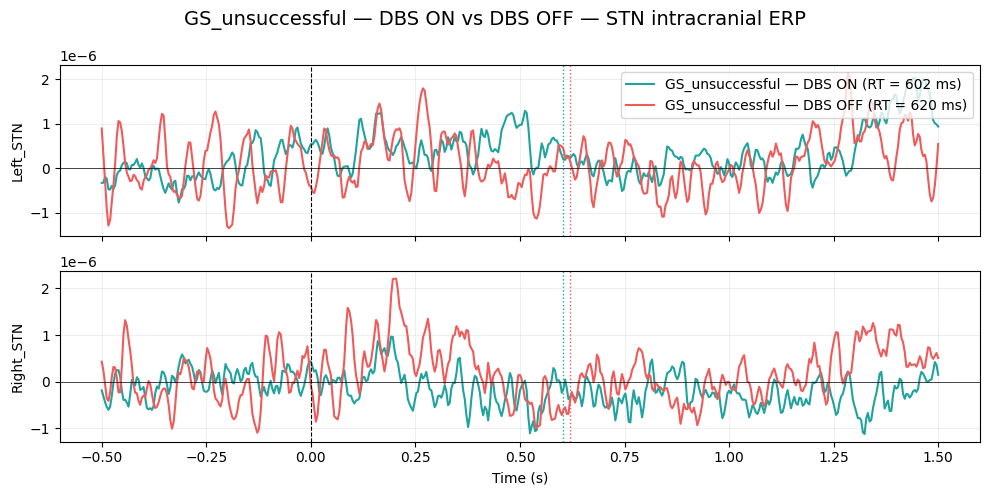

In [14]:
temp_save = os.path.join(saving_path_on_off, 'GS')
if not os.path.exists(temp_save):
    os.makedirs(temp_save)

epoch_cond = 'GS_unsuccessful'

avg_on, avg_off, cluster_results, subjects_included, mean_rt_on, mean_rt_off, rt_by_subject = ephy_meta_function.stn_erp_change_diff_on_off(
    sub_dict_epochs=sub_dict_epochs,
    epoch_cond=epoch_cond,
    condition_color_dict=color_dict,
    saving_path=temp_save,
    alpha=0.05,
    n_permutations=1000,
    save_as='png'
)

Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)

Number of paired subjects included: 11
Subjects: ['sub006  mSST', 'sub011  

  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

Using a threshold of 2.228139
stat_fun(H1): min=-2.2453923295243663 max=4.068579190270208
Running initial clustering …
Found 11 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

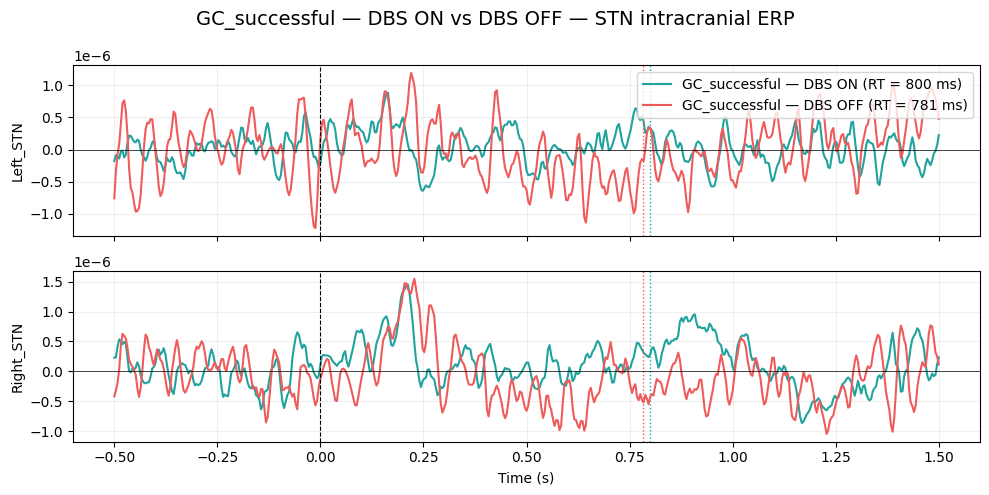

In [15]:
temp_save = os.path.join(saving_path_on_off, 'GC')
if not os.path.exists(temp_save):
    os.makedirs(temp_save)

epoch_cond = 'GC_successful'

avg_on, avg_off, cluster_results, subjects_included, mean_rt_on, mean_rt_off, rt_by_subject = ephy_meta_function.stn_erp_change_diff_on_off(
    sub_dict_epochs=sub_dict_epochs,
    epoch_cond=epoch_cond,
    condition_color_dict=color_dict,
    saving_path=temp_save,
    alpha=0.05,
    n_permutations=1000,
    save_as='png'
)

# 4. ERP DIFFERENT ANALYSIS #

In [8]:
erp_saving_path_group = "C:\\Users\\Juliette\\Research\\Projects\\analysis_mSST\\results\\group_level\\erp"

In [18]:
# =========================
# FULL ERP PIPELINE – ONE CELL (WITH COMPARISON PLOT)
# =========================

import os
import numpy as np
import matplotlib.pyplot as plt
import mne

def get_erp_decomposition(
        epochs,
        cond_of_interest,
        ch_names,
        baseline_correction=True,
        tmin_tmax=[-0.2, 0.8]
):
    """
    Returns average ERP for one subject, one condition, one ROI
    """

    # ---- Parse condition ----
    epoch_type, outcome_str, aligned_str = cond_of_interest.split('_')
    outcome = 1.0 if outcome_str == "successful" else 0.0

    # ---- Select epochs ----
    type_mask = epochs.metadata["event"] == epoch_type
    outcome_mask = epochs.metadata["key_resp_experiment.corr"] == outcome
    data = epochs[type_mask & outcome_mask]

    if len(data) == 0:
        return None, None, None, None

    # ---- RT / SSD ----
    rt = np.asarray(data.metadata['key_resp_experiment.rt'])
    mean_rt = np.nanmean(rt) if np.any(~np.isnan(rt)) else None

    ssd = None
    if epoch_type == 'GS':
        ssd = np.asarray(data.metadata['stop_signal_time'])
    elif epoch_type == 'GC':
        ssd = np.asarray(data.metadata['continue_signal_time'])
    mean_ssd = np.nanmean(ssd) if ssd is not None else None

    # ---- Pick channels ----
    data = data.copy().pick(ch_names)

    # ---- ERP data ----
    # shape: (n_epochs, n_channels, n_times)
    X = data.get_data() * 1e6  # V → µV

    # average over channels
    X = np.nanmean(X, axis=1)  # (n_epochs, n_times)

    # average over trials
    erp = np.nanmean(X, axis=0)  # (n_times,)

    times = data.times * 1000  # ms

    # ---- Baseline correction FIRST ----
    if baseline_correction:
        bmask = (times >= -200) & (times <= 0)
        if np.any(bmask):
            baseline = np.nanmean(erp[bmask])
            erp = erp - baseline
        else:
            # fail silently but safely
            erp = erp * np.nan

    # ---- Crop AFTER baseline ----
    tmask = (times >= tmin_tmax[0] * 1000) & (times <= tmin_tmax[1] * 1000)
    erp = erp[tmask]
    times = times[tmask]

    # # ---- Crop ----
    # tmask = (times >= tmin_tmax[0] * 1000) & (times <= tmin_tmax[1] * 1000)
    # erp = erp[tmask]
    # times = times[tmask]

    # # ---- Baseline correction ----
    # if baseline_correction:
    #     bmask = (times >= -200) & (times <= 0)
    #     baseline = np.nanmean(erp[bmask])
    #     erp = erp - baseline

    return erp, times, mean_rt, mean_ssd


# ------------------------------
# Single-condition ERP plot (with RT)
# ------------------------------
# ------------------------------
# Single-condition ERP plot (with RT line)
# ------------------------------
def plot_erp_result(
        group,
        all_erps,
        times,
        epochs_cond,
        roi,
        sub_num,
        saving_path,
        mean_rt_all=None,
        save_as='png'
):

    avg = np.nanmean(all_erps, axis=0)
    sem = np.nanstd(all_erps, axis=0) / np.sqrt(all_erps.shape[0])

    fig, ax = plt.subplots(figsize=(6, 4))
    ax.plot(times, avg, label=epochs_cond)
    ax.fill_between(times, avg - sem, avg + sem, alpha=0.3)

    # Event lines
    ax.axvline(0, color='red', linestyle='--', label='Cue')
    
    # Mean RT line
    print(f"Mean RTs for {group} | {epochs_cond} | {roi}: {mean_rt_all}")
    if mean_rt_all is not None and len(mean_rt_all) > 0:
        mean_rt = np.nanmean(mean_rt_all)
        ax.axvline(mean_rt*1000, color='blue', linestyle='--', label=f'Mean RT ({mean_rt:.1f} ms)')

    ax.axhline(0, color='gray', linestyle=':')

    ax.set_xlabel("Time (ms)")
    ax.set_ylabel("Amplitude (µV)")
    ax.set_title(f"{group} | {epochs_cond} | {roi} | n={sub_num}")
    ax.legend()

    os.makedirs(saving_path, exist_ok=True)
    fig.savefig(
        os.path.join(saving_path, f"{group}_{epochs_cond}_{roi}_ERP.{save_as}"),
        dpi=300,
        bbox_inches='tight'
    )
    plt.show(fig)


# ------------------------------
# Comparison plot (two conditions, with RT lines)
# ------------------------------
def plot_erp_comparison(
        group,
        erp_dict,
        times,
        roi,
        sub_num,
        mean_rt_dict=None,
        saving_path=None,
        save_as='png'
):
    fig, ax = plt.subplots(figsize=(6, 4))

    colors = ['black', 'green']  # adjust for two conditions
    for i, (cond, all_erps) in enumerate(erp_dict.items()):
        avg = np.nanmean(all_erps, axis=0)
        sem = np.nanstd(all_erps, axis=0) / np.sqrt(all_erps.shape[0])

        ax.plot(times, avg, color=colors[i], label=cond)
        ax.fill_between(times, avg - sem, avg + sem, alpha=0.25, color=colors[i])

        # Mean RT line per condition
        if mean_rt_dict is not None and cond in mean_rt_dict and len(mean_rt_dict[cond]) > 0:
            mean_rt = np.nanmean(mean_rt_dict[cond])
            ax.axvline(mean_rt*1000, color=colors[i], linestyle='--', alpha=0.7,
                       label=f'{cond} Mean RT ({mean_rt:.1f} ms)')

    ax.axvline(0, color='red', linestyle='--', label='Cue')
    ax.axhline(0, color='gray', linestyle=':')

    ax.set_xlabel("Time (ms)")
    ax.set_ylabel("Amplitude (µV)")
    ax.set_title(f"{group} | {roi} | n={sub_num}")
    ax.legend()

    os.makedirs(saving_path, exist_ok=True)
    fig.savefig(
        os.path.join(saving_path, f"{group}_ERP_COMPARISON_{roi}.{save_as}"),
        dpi=300,
        bbox_inches='tight'
    )
    plt.show(fig)


def meta_function_erp_intra_group(
        tfr_dict,
        sub_group,
        sub_dict_epochs,
        single_sub,
        epochs_cond,
        roi,
        tmin_tmax,
        plot_single_condition,
        baseline_correction,
        saving_path,
        save_as='png'
):

    if sub_group not in tfr_dict:
        tfr_dict[sub_group] = {}

    comparison_store = {}
    mean_rt_store = {}

    group_key = sub_group if 'DBS' in sub_group else 'C'
    selected_epochs = {
        k: v for k, v in sub_dict_epochs.items() if group_key in k
    }

    for coi in epochs_cond:

        all_erps = []
        subs = []
        mean_rt_all = []

        for sub, epochs in selected_epochs.items():

            erp, times, mean_rt, _ = get_erp_decomposition(
                epochs,
                coi,
                roi,
                baseline_correction,
                tmin_tmax
            )

            if erp is None:
                continue

            all_erps.append(erp)
            subs.append(sub)
            if mean_rt is not None:
                mean_rt_all.append(mean_rt)

        if len(all_erps) == 0:
            continue

        min_len = min(e.shape[0] for e in all_erps)
        all_erps = np.stack([e[:min_len] for e in all_erps])
        times = times[:min_len]

        sub_num = len(subs)

        if plot_single_condition:
            plot_erp_result(
                sub_group,
                all_erps,
                times,
                coi,
                roi,
                sub_num,
                saving_path,
                mean_rt_all=mean_rt_all,
                save_as=save_as
            )

        tfr_dict[sub_group][coi] = {
            'all_erps': all_erps,
            'times': times,
            'mean_rt_all': mean_rt_all
        }

        comparison_store[coi] = all_erps
        mean_rt_store[coi] = mean_rt_all

    # ---- COMPARISON PLOT ----
    if len(comparison_store) == 2:
        plot_erp_comparison(
            group=sub_group,
            erp_dict=comparison_store,
            times=times,
            roi=roi,
            sub_num=sub_num,
            mean_rt_dict=mean_rt_store,
            saving_path=saving_path,
            save_as=save_as
        )

    return tfr_dict


## 4.1. Proactive inhibition ##

Mean RTs for DBS OFF | GF_successful_square | ['Left_STN']: [0.5253931775862068, 0.664408602932353, 0.6448667924528301, 0.6566722493467533, 0.5273966413982759, 0.61159834795, 0.5517331632653062, 0.5966232142857143, 0.4992494000086207, 0.5874053216666666, 0.578118687755102]


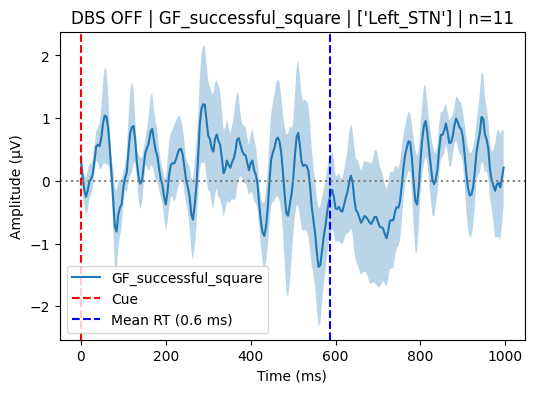

Mean RTs for DBS OFF | GO_successful_square | ['Left_STN']: [0.6499181601226993, 0.6994852951451456, 0.6674427888198758, 0.7313646793399062, 0.6574621476697675, 0.5750533932912751, 0.6000558746582191, 0.6007247928143713, 0.6591957572277108, 0.8145845045801526, 0.7917641055118109]


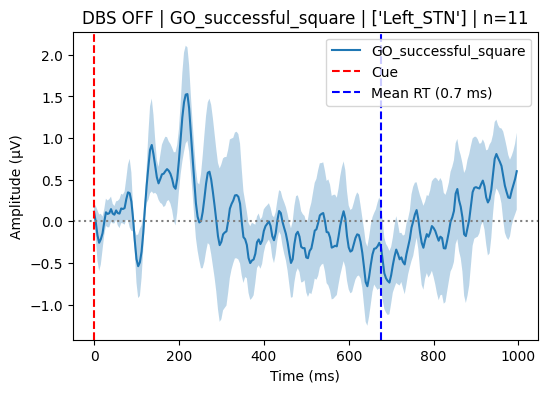

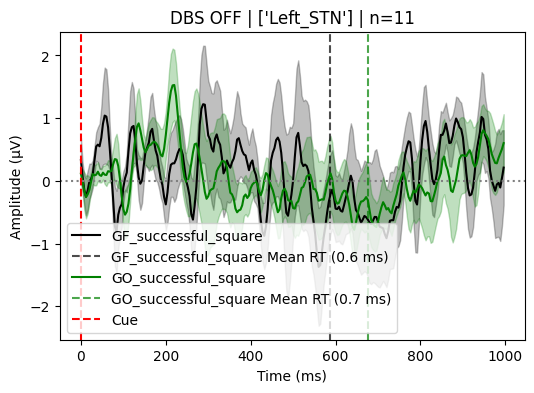

Mean RTs for DBS ON | GF_successful_square | ['Left_STN']: [0.6059419103818181, 0.6072259145581816, 0.6847159423211537, 0.5808779192912281, 0.6028753961090908, 0.5865876548843136, 0.573520322211111, 0.5363190624999999, 0.45414226442542377, 0.5362025396551725, 0.5416333471698114]


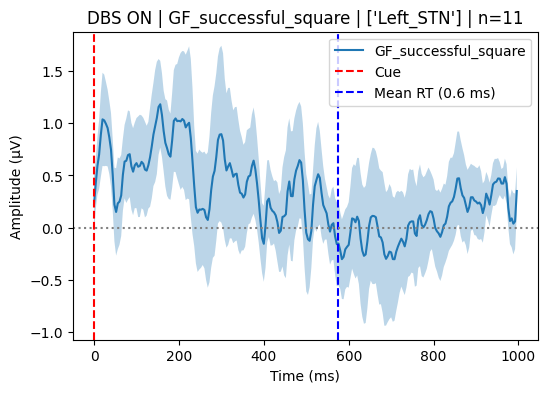

Mean RTs for DBS ON | GO_successful_square | ['Left_STN']: [0.6972862085390373, 0.7188499961878981, 0.6487428956802469, 0.7360444229751553, 0.684075068698598, 0.55949814564125, 0.6316595019147436, 0.6209681161016949, 0.6303815557408046, 0.778554252027027, 0.758659973943662]


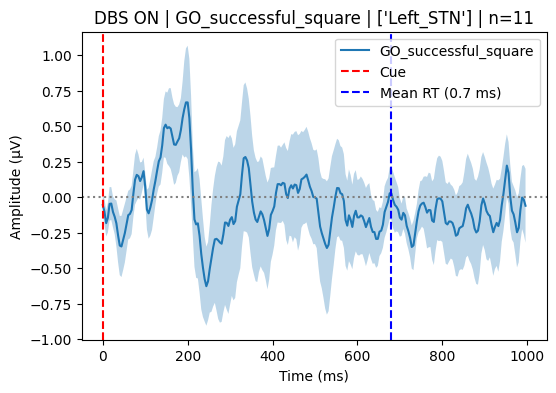

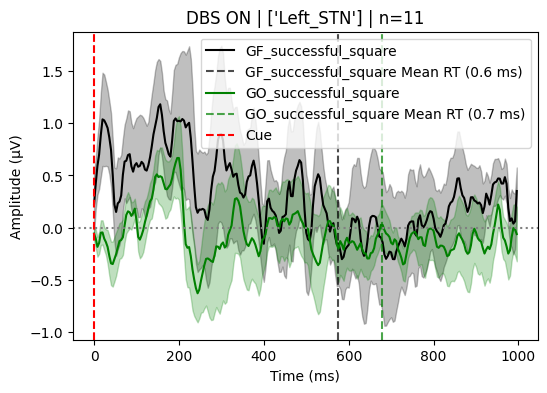

Mean RTs for DBS OFF | GF_successful_square | ['Right_STN']: [0.5253931775862068, 0.664408602932353, 0.6448667924528301, 0.6566722493467533, 0.5273966413982759, 0.61159834795, 0.5517331632653062, 0.5966232142857143, 0.4992494000086207, 0.5874053216666666, 0.578118687755102]


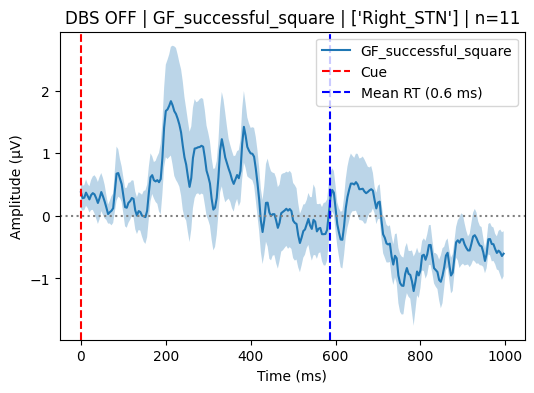

Mean RTs for DBS OFF | GO_successful_square | ['Right_STN']: [0.6499181601226993, 0.6994852951451456, 0.6674427888198758, 0.7313646793399062, 0.6574621476697675, 0.5750533932912751, 0.6000558746582191, 0.6007247928143713, 0.6591957572277108, 0.8145845045801526, 0.7917641055118109]


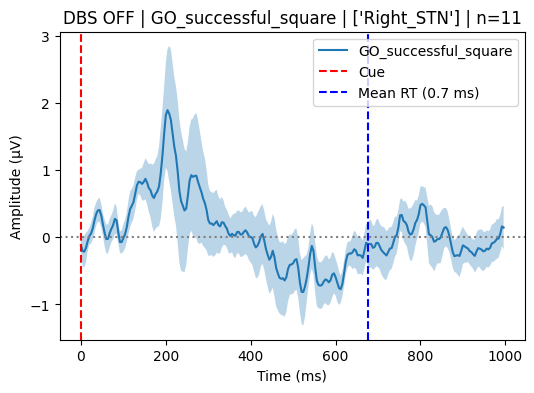

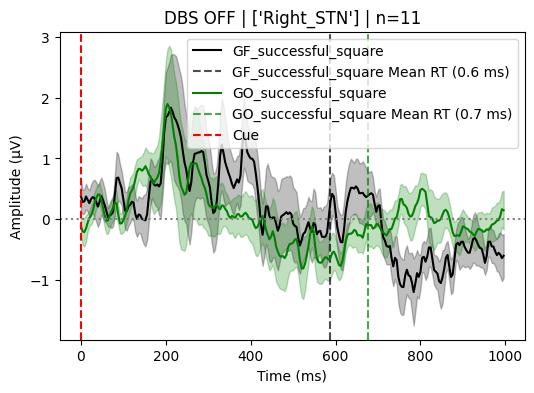

Mean RTs for DBS ON | GF_successful_square | ['Right_STN']: [0.6059419103818181, 0.6072259145581816, 0.6847159423211537, 0.5808779192912281, 0.6028753961090908, 0.5865876548843136, 0.573520322211111, 0.5363190624999999, 0.45414226442542377, 0.5362025396551725, 0.5416333471698114]


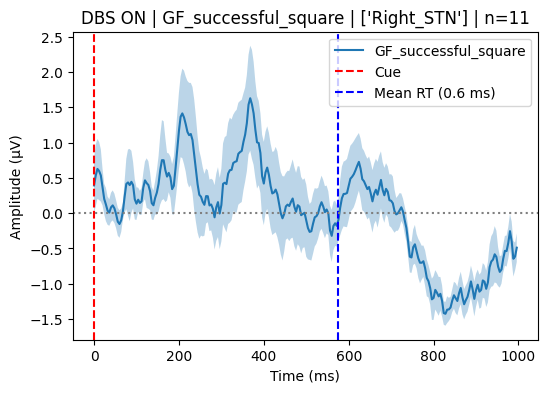

Mean RTs for DBS ON | GO_successful_square | ['Right_STN']: [0.6972862085390373, 0.7188499961878981, 0.6487428956802469, 0.7360444229751553, 0.684075068698598, 0.55949814564125, 0.6316595019147436, 0.6209681161016949, 0.6303815557408046, 0.778554252027027, 0.758659973943662]


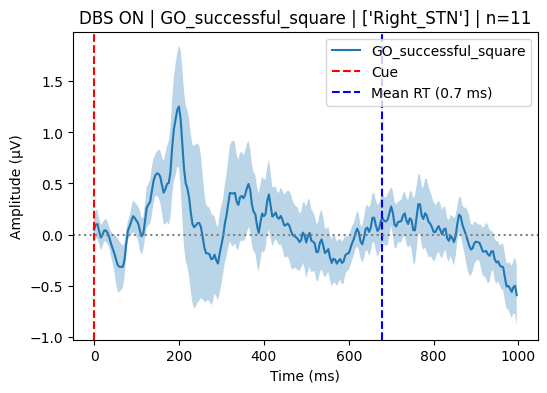

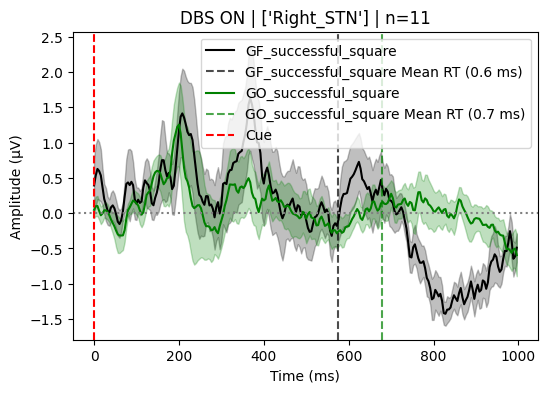

In [24]:
temp_save = os.path.join(erp_saving_path_group, 'proactive inhibition')
if not os.path.exists(temp_save):
    os.makedirs(temp_save)
tfr_dict = {}
epochs_cond = [
    #'GS_successful_feedback', 
    #'GS_unsuccessful_feedback', 
    # 'GC_successful_response',
    # 'GS_unsuccessful_response',
    'GF_successful_square',
    # 'GC_successful_square',
    # 'GS_unsuccessful_square',
    'GO_successful_square',
    # 'GC_successful_square',
    # 'GO_successful_square',
    # 'GC_successful_triangle',
    # 'GS_unsuccessful_triangle',
    # 'GS_successful_triangle',
    # 'GS_successful_feedback',
    # 'GS_unsuccessful_feedback',
    # 'GO_successful_feedback',
    # 'GF_successful_feedback'
    ]
# roi = ['Left_STN']

for roi in [['Left_STN'], ['Right_STN']]:
    for sub_group in ['DBS OFF', 'DBS ON']:
        tfr_dict = meta_function_erp_intra_group(
            tfr_dict = tfr_dict,
            sub_group = sub_group,
            sub_dict_epochs = sub_dict_epochs,
            single_sub = False,
            epochs_cond = epochs_cond,
            roi = roi,
            tmin_tmax = [0, 1],
            plot_single_condition = True,
            baseline_correction = True,
            saving_path = temp_save,
            save_as='png'
            )

## 4.2. Reactive inhibition ##

Mean RTs for DBS OFF | GS_successful_square | ['Left_STN']: []


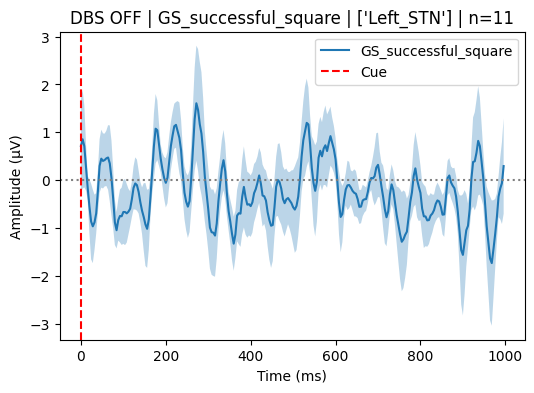

Mean RTs for DBS OFF | GO_successful_square | ['Left_STN']: [0.6499181601226993, 0.6994852951451456, 0.6674427888198758, 0.7313646793399062, 0.6574621476697675, 0.5750533932912751, 0.6000558746582191, 0.6007247928143713, 0.6591957572277108, 0.8145845045801526, 0.7917641055118109]


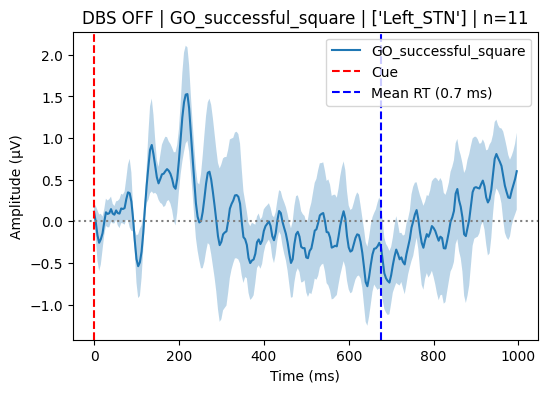

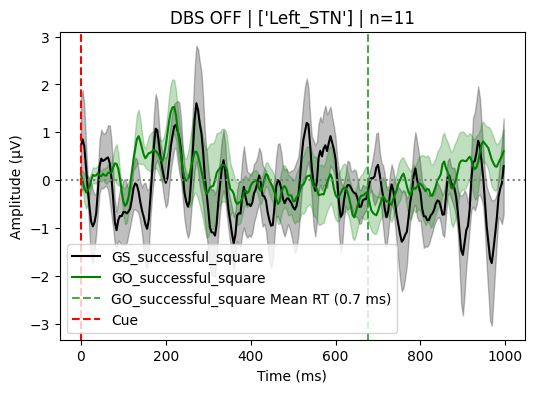

Mean RTs for DBS ON | GS_successful_square | ['Left_STN']: []


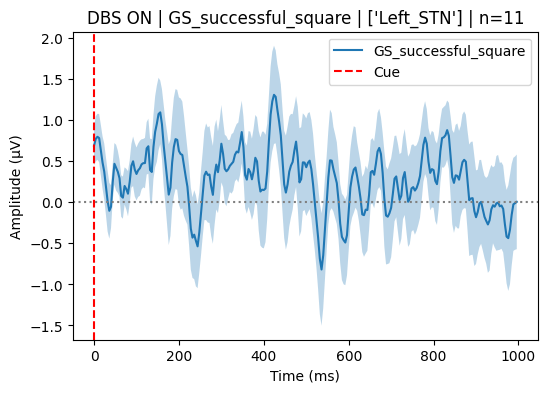

Mean RTs for DBS ON | GO_successful_square | ['Left_STN']: [0.6972862085390373, 0.7188499961878981, 0.6487428956802469, 0.7360444229751553, 0.684075068698598, 0.55949814564125, 0.6316595019147436, 0.6209681161016949, 0.6303815557408046, 0.778554252027027, 0.758659973943662]


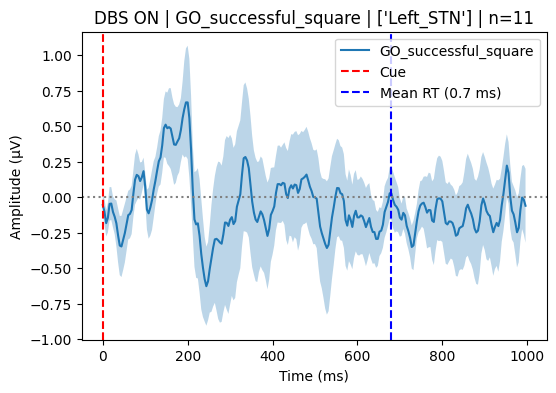

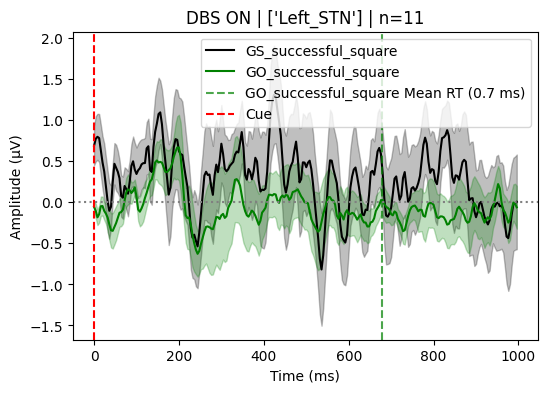

Mean RTs for DBS OFF | GS_successful_square | ['Right_STN']: []


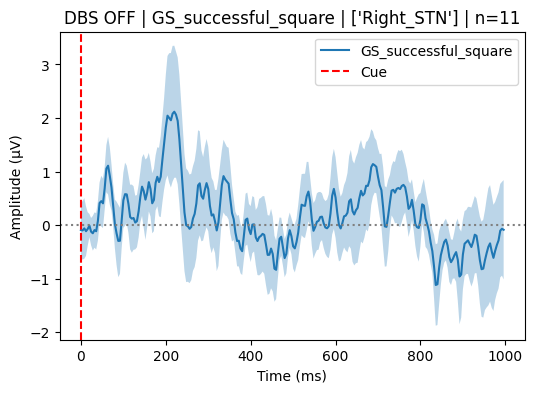

Mean RTs for DBS OFF | GO_successful_square | ['Right_STN']: [0.6499181601226993, 0.6994852951451456, 0.6674427888198758, 0.7313646793399062, 0.6574621476697675, 0.5750533932912751, 0.6000558746582191, 0.6007247928143713, 0.6591957572277108, 0.8145845045801526, 0.7917641055118109]


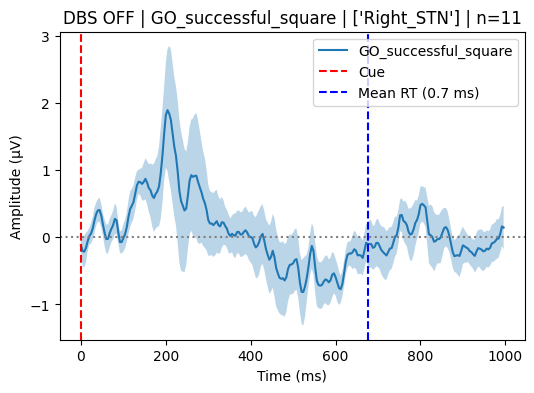

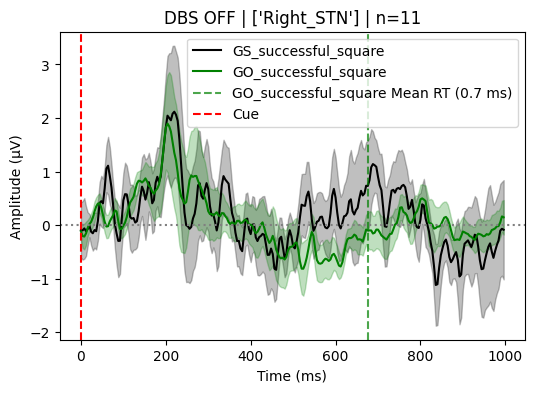

Mean RTs for DBS ON | GS_successful_square | ['Right_STN']: []


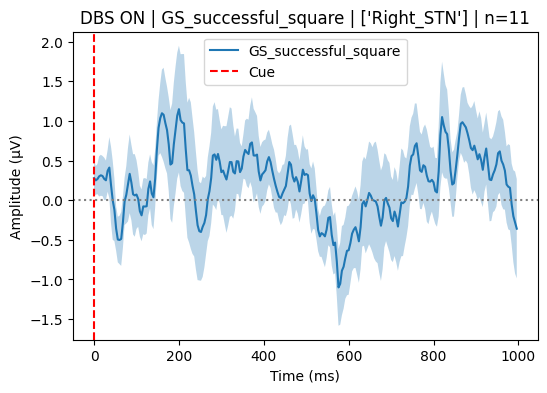

Mean RTs for DBS ON | GO_successful_square | ['Right_STN']: [0.6972862085390373, 0.7188499961878981, 0.6487428956802469, 0.7360444229751553, 0.684075068698598, 0.55949814564125, 0.6316595019147436, 0.6209681161016949, 0.6303815557408046, 0.778554252027027, 0.758659973943662]


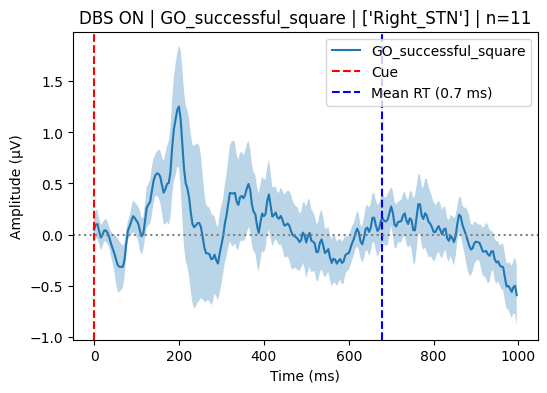

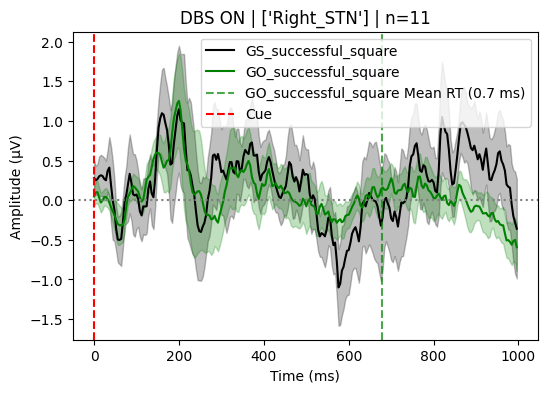

In [25]:
temp_save = os.path.join(erp_saving_path_group, 'reactive inhibition')
if not os.path.exists(temp_save):
    os.makedirs(temp_save)
tfr_dict = {}
epochs_cond = [
    #'GS_successful_feedback', 
    #'GS_unsuccessful_feedback', 
    # 'GC_successful_response',
    # 'GS_unsuccessful_response',
    # 'GF_successful_square',
    # 'GC_successful_square',
    # 'GS_unsuccessful_square',
    'GS_successful_square',
    'GO_successful_square',
    # 'GC_successful_square',
    # 'GO_successful_square',
    # 'GC_successful_triangle',
    # 'GS_unsuccessful_triangle',
    # 'GS_successful_triangle',
    # 'GS_successful_feedback',
    # 'GS_unsuccessful_feedback',
    # 'GO_successful_feedback',
    # 'GF_successful_feedback'
    ]
# roi = ['Left_STN']
for roi in [['Left_STN'], ['Right_STN']]:
    for sub_group in ['DBS OFF', 'DBS ON']:
        tfr_dict = meta_function_erp_intra_group(
            tfr_dict = tfr_dict,
            sub_group = sub_group,
            sub_dict_epochs = sub_dict_epochs,
            single_sub = False,
            epochs_cond = epochs_cond,
            roi = roi,
            tmin_tmax = [0, 1],
            plot_single_condition = True,
            baseline_correction = True,
            saving_path = temp_save,
            save_as='png'
            )

Plot power change for different constrasts, for each single subject and each condition/trial type

Contrasts of interest are:

    - GS_successful - GO_successful  --> reactive inhibition contrast

    - GO_successful - GF_successful  --> proactive inhibition contrast

    - GS_successful - GS_unsuccessful  --> stopping contrast

    - STOP_successful - STOP_unsuccessful --> stopping contrast but aligned to the STOP cue
    
    - STOP_successful - CONTINUE_successful --> attentional contrast aligned to the unexpected stimuli

In [ ]:
sub_dict_epochs

## 4.1. Resample ##

In [ ]:
new_sf = 250

resampled_sub_dict_epochs = {}

for subject, data in sub_dict_epochs.items():
    resampled_sub_dict_epochs[subject] = data.copy().resample(sfreq=new_sf)


## 4.2. Set parameters : Band to investigate, conditions to investigate, conditions to test against each other, colour schemes ##

In [ ]:
freq_band = (13, 20)
band_name = "Low Beta"

conds_of_interest = ['GO_successful', 'GF_successful', 'GS_successful']

cond_colours = {'GO_successful': 'orange', 'GF_successful': 'green', 'GS_successful': 'red'}

test_cond_dict = {
    "GO vs GS": ("GO_successful", "GS_successful"),
    "GO vs GF":   ("GO_successful", "GF_successful")
}

test_off_on_conds = ['GO_successful', 'GF_successful', 'GS_successful']

off_vs_on_colours = { "OFF": "black", "ON": "red" }

# Define baseline window (seconds)
BASELINE_START = -0.5
BASELINE_END   = -0.2

# Define analysis window (seconds)
ANALYSIS_START = -0.5  
ANALYSIS_END   = 1.5   

## 4.3. Bandpass filter, and smooth data ##

Smoothing reduces noise (due to trial-to-trial variability) and moment-to-moment variability that's (likely) not meaningful.

Each trial is filtered and smoothed separately, then they are averaged at the end.

In [ ]:
import scipy

Whole trial

In [ ]:
### Parameters ###
sfreq = new_sf                    # sf of resampled data
freq_band = freq_band             # default band to fall back to (e.g., (13, 20))
order = 4                         # Butterworth filter order
fwhm_ms = 120                     # Gaussian smoothing width (FWHM) in ms (try different between 100–150)
#band_width_hz = 5.0               # half-width around the peak (±5 Hz)
band_width_hz = 5.0
nyq = sfreq / 2

# Convert FWHM (ms) -> sigma (samples) for gaussian_filter1d
sigma_samples = (fwhm_ms / 1000.0) * sfreq / 2.355  

# Output dict
band_power_dict = {}      # Average power in each condition, left and right STN
trial_power_smooth = {}   # Per-trial smoothed power for contra/ipsi
trial_meta = {}           # Times and corr_button per condition, useful for contra/ipsi analyses

# Loop through subjects and conditions
for subj, cue_epochs in resampled_sub_dict_epochs.items():
    band_power_dict[subj] = {}
    trial_power_smooth[subj] = {}
    trial_meta[subj] = {}

    # Subject's L/R peaks with per-hemisphere, uses default freq_band if no peak is identified. 
    # pm = peaks_map.get(subj, {})
    # pkL_raw = pm.get("left")
    # pkR_raw = pm.get("right")

    # pkLeft  = float(pkL_raw)  if pkL_raw is not None else np.nan
    # pkRight = float(pkR_raw)  if pkR_raw is not None else np.nan
    # pkLeft, pkRight = (np.nan, np.nan)  # No peaks available, always use default band

    # use_default_L = not np.isfinite(pkLeft)
    # use_default_R = not np.isfinite(pkRight)

    # # Per-hemisphere bands (either centered on peak ±band_width_hz, or default freq_band)
    # lowLeft,  highLeft  = (freq_band if use_default_L else (pkLeft  - band_width_hz, pkLeft  + band_width_hz))
    # lowRight, highRight = (freq_band if use_default_R else (pkRight - band_width_hz, pkRight + band_width_hz))

    # # Design filters
    # bL, aL = scipy.signal.butter(N=order, Wn=np.array([lowLeft,  highLeft ]) / nyq, btype="bandpass")
    # bR, aR = scipy.signal.butter(N=order, Wn=np.array([lowRight, highRight]) / nyq, btype="bandpass")

    for full_cond in conds_of_interest:
        cond = full_cond.split('_')[0]
        outcome_str = full_cond.split('_')[1]
        outcome = 1.0 if outcome_str == 'successful' else 0.0

        if cond not in cue_epochs.event_id:
            continue

        type_mask = cue_epochs.metadata["event"] == cond
        outcome_mask = cue_epochs.metadata["key_resp_experiment.corr"] == outcome
        ep = cue_epochs[type_mask & outcome_mask]

        # data shape: (n_trials, n_channels, n_times), # convert to µV
        data = ep.get_data() #* 1e6
        filtered = data.copy()

        # # Bandpass filter (zero-phase)
        # filtered = np.empty_like(data)
        # filtered[:, 0, :] = scipy.signal.filtfilt(bL, aL, data[:, 0, :], axis=-1)  # Left STN
        # filtered[:, 1, :] = scipy.signal.filtfilt(bR, aR, data[:, 1, :], axis=-1)  # Right STN

        # Power (square the bandpassed signal)
        beta_power = filtered ** 2  # (n_trials, n_channels, n_times)

        # Smooth power per trial along time with Gaussian (zero-phase via symmetric kernel)
        # - mode='reflect' avoids edge flattening
        # - truncate=3.0 -> kernel spans ±3σ
        trial_smoothed = scipy.ndimage.gaussian_filter1d(
            beta_power,
            sigma=sigma_samples,
            axis=-1,
            mode='reflect',
            truncate=3.0
        )  # (n_trials, n_channels, n_times)

        # Average trials(n_channels, n_times)
        avg_power = np.nanmean(trial_smoothed, axis=0)

        # Store average power
        band_power_dict[subj][full_cond] = avg_power

        # Store per-trial smoothed power + metadata info for contra/ipsi creating later
        trial_power_smooth[subj][full_cond] = trial_smoothed
        trial_meta[subj][full_cond] = {
            "times": ep.times,
            "corr_button": (ep.metadata["corr_button"].astype(str).to_numpy()
                if (ep.metadata is not None and "corr_button" in ep.metadata.columns)
                else None)}

        # pkL_txt = "default" if use_default_L else f"{pkLeft:.2f}"
        # pkR_txt = "default" if use_default_R else f"{pkRight:.2f}"
        # print(f"{subj} - {full_cond}: "
        #       f"L {lowLeft:.1f}–{highLeft:.1f} Hz (pk {pkL_txt}), "
        #       f"R {lowRight:.1f}–{highRight:.1f} Hz (pk {pkR_txt}); "
        #       f"avg power shape {avg_power.shape}, FWHM={fwhm_ms} ms (σ≈{sigma_samples:.2f} samples)")

Baseline

In [ ]:
# Parameters
# sfreq = new_sf                    # Sampling frequency (Hz)
# order = 4                         # Filter order
# smooth_window_ms = 120            # Gaussian FWHM in ms (try 100–150)
# fwhm_ms = smooth_window_ms        # keep naming consistent with earlier code
# #band_width_hz = 5.0               # half-width around the peak (±5 Hz)
# nyq = sfreq / 2.0

# Convert FWHM (ms) -> sigma (samples) for gaussian_filter1d:
# ms -> s -> samples (× sfreq), then sigma = FWHM / 2.355
# sigma_samples = (fwhm_ms / 1000.0) * sfreq / 2.355

# Output dict
band_baseline_power_dict = {}

# Loop through subjects and baseline epochs
for subj, raw_epochs in resampled_sub_dict_epochs.items():

    # --- Subject's L/R peaks with per-hemisphere fallback to default freq_band ---
    # pm = peaks_map.get(subj, {})
    # pkL_raw = pm.get("left")
    # pkR_raw = pm.get("right")

    # pkLeft  = float(pkL_raw)  if pkL_raw  is not None else np.nan
    # pkRight = float(pkR_raw)  if pkR_raw  is not None else np.nan
    # pkLeft, pkRight = (np.nan, np.nan)  # No peaks available, always use default band

    # use_default_L = not np.isfinite(pkLeft)
    # use_default_R = not np.isfinite(pkRight)

    # # Per-hemisphere bands (either centered on peak ±band_width_hz, or default freq_band)
    # lowLeft,  highLeft  = (freq_band if use_default_L else (pkLeft  - band_width_hz, pkLeft  + band_width_hz))
    # lowRight, highRight = (freq_band if use_default_R else (pkRight - band_width_hz, pkRight + band_width_hz))

    # # Design zero-phase Butterworth bandpasses (one per hemisphere)
    # bL, aL = scipy.signal.butter(N=order, Wn=np.array([lowLeft,  highLeft ]) / nyq, btype='bandpass')
    # bR, aR = scipy.signal.butter(N=order, Wn=np.array([lowRight, highRight]) / nyq, btype='bandpass')

    # Get data (n_trials, n_channels, n_times), convert to µV 
    data = raw_epochs.get_data() #* 1e6
    filtered = data.copy()

    # # Bandpass filter (zero-phase), per hemisphere
    # filtered = np.empty_like(data)
    # filtered[:, 0, :] = scipy.signal.filtfilt(bL, aL, data[:, 0, :], axis=-1)  # Left STN
    # filtered[:, 1, :] = scipy.signal.filtfilt(bR, aR, data[:, 1, :], axis=-1)  # Right STN

    # Power (square the bandpassed signal)
    band_power = filtered ** 2  # (n_trials, 2, n_times)

    # Smooth power per trial along time with Gaussian (zero-phase via symmetric kernel)
    # - mode='reflect' avoids edge flattening
    # - truncate=3.0 -> kernel spans ±3σ
    trial_smoothed = scipy.ndimage.gaussian_filter1d(
        band_power,
        sigma=sigma_samples,
        axis=-1,
        mode='reflect',
        truncate=3.0
    )  # (n_trials, 2, n_times)

    # Average across trials -> (2, n_times)
    avg_power = np.nanmean(trial_smoothed, axis=0)

    # Store
    band_baseline_power_dict[subj] = {
        'power': avg_power,           # (2, n_times)
        'times': raw_epochs.times     # (n_times,)
    }

    # pkL_txt = "default" if use_default_L else f"{pkLeft:.2f}"
    # pkR_txt = "default" if use_default_R else f"{pkRight:.2f}"
    # print(f"{subj}: baseline L {lowLeft:.1f}–{highLeft:.1f} Hz (pk {pkL_txt}), "
    #       f"R {lowRight:.1f}–{highRight:.1f} Hz (pk {pkR_txt}) | "
    #       f"smoothed baseline power {avg_power.shape} | "
    #       f"FWHM={fwhm_ms} ms (σ≈{sigma_samples:.2f} samples)")

Freq band power change and percentage change from baseline
Left and right STN separately

In [ ]:
# Storing the output
cusum_by_subject: dict = {}

for subject_id, mean_power_by_condition in band_power_dict.items():
    cusum_by_subject[subject_id] = {}

    # Baseline (averaged, smoothed): (n_channels, n_times)
    baseline_power = band_baseline_power_dict[subject_id]['power']
    baseline_times = band_baseline_power_dict[subject_id]['times']  # (n_times,)

    # Time indices for the baseline window
    baseline_mask = (baseline_times >= BASELINE_START) & (baseline_times <= BASELINE_END)

    # Mean baseline power per channel: (n_channels, 1)
    baseline_mean_per_channel = np.nanmean(
        baseline_power[:, baseline_mask], axis=1, keepdims=True
    )

    # Loop through each condition
    for cond in conds_of_interest:
        if cond not in mean_power_by_condition:
            continue

        # Mean beta power (smoothed, averaged) for this condition (n_channels, n_times)
        mean_power_per_channel_time = mean_power_by_condition[cond]

        # Times for the condition (used for plotting/interpretation)
        times = resampled_sub_dict_epochs[subject_id][cond.split('_')[0]].times  # (n_times,)

        # Slice to analysis window of interest
        mask = (times >= ANALYSIS_START) & (times < ANALYSIS_END)
        if not mask.any():
            raise ValueError(f"No samples in analysis window for {subject_id} - {cond}")

        mean_power_win = mean_power_per_channel_time[:, mask]  # (n_channels, n_times_in_win)
        times_win = times[mask]

        # sizes for logging
        n_channels, n_times = mean_power_win.shape

        # CUSUM relative to baseline (per channel)
        cusum_raw_per_channel_time = np.cumsum(mean_power_win - baseline_mean_per_channel, axis=-1)  # (n_channels, n_times)
        cusum_pct_per_channel_time = (cusum_raw_per_channel_time / (baseline_mean_per_channel)) * 100.0  # (n_channels, n_times)

        # Derivative of cumulative % change, i.e., instantaneous % change per second
        # Percentage change per second (derivative of cusum)
        dt = np.mean(np.diff(times_win))  # in seconds
        cusum_pct_change_rate_per_channel_time = np.gradient(cusum_pct_per_channel_time, dt, axis=-1)

        # Store results
        cusum_by_subject[subject_id][cond] = {
            'times_sec': times_win,  # (n_times,)
            'mean_power_per_channel_time': mean_power_per_channel_time,  # (n_channels, n_times)
            'baseline_mean_per_channel': baseline_mean_per_channel,      # (n_channels, 1)
            'cusum_raw_per_channel_time': cusum_raw_per_channel_time,    # (n_channels, n_times)
            'cusum_pct_per_channel_time': cusum_pct_per_channel_time,    # (n_channels, n_times)
            'cusum_pct_change_rate_per_channel_time': cusum_pct_change_rate_per_channel_time,  # (n_channels, n_times)
        }

        print(
            f"{subject_id} - {cond}: "
            f"n_channels={n_channels}, n_times={n_times} | "
            f"baseline_mean_per_channel shape={baseline_mean_per_channel.shape}"
        )

In [ ]:
import matplotlib.pyplot as plt

In [ ]:
# Inputs
subject = "sub006 DBS OFF mSST"
condition = "GO_successful"
use_percentage = True  # False for raw CUSUM (µV²)

channel_labels = ['STN Left', 'STN Right']
channel_colors = ['blue', 'green']

# Data
entry = cusum_by_subject[subject][condition]
times = entry['times_sec']  # already cropped if you used Option A
cusum = entry['cusum_pct_per_channel_time'] if use_percentage else entry['cusum_raw_per_channel_time']
ylabel = "Cumulative % change in β power" if use_percentage else "CUSUM (µV²)"

# Plot
plt.figure(figsize=(12, 5))
for ch in range(min(2, cusum.shape[0])):  # plot first two channels
    y = cusum[ch]
    # OPTIONAL: Curve starts at 0 at the left edge of the window
    # y = y - y[0]
    plt.plot(times, y, label=channel_labels[ch], color=channel_colors[ch])

plt.axhline(0, color='k', linestyle='--', linewidth=1)
plt.axvline(0, color='k', linestyle=':', linewidth=1)  # optional cue line

plt.title(f"{subject}: {condition} - {band_name}")
plt.xlabel("Time (s)")
plt.ylabel(ylabel)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

# Remove the default x axis padding so there’s no white space at end of fig.
ax = plt.gca()
ax.set_xlim(times[0], times[-1])
ax.margins(x=0)

plt.show()

In [ ]:
# Inputs
subject = "sub006 DBS OFF mSST"
condition = "GO_successful"
use_percentage = True  # False for raw CUSUM (µV²)

channel_labels = ['STN Left', 'STN Right']
channel_colors = ['blue', 'green']

# Data
entry = cusum_by_subject[subject][condition]
times = entry['times_sec']  # already cropped if you used Option A
cusum = entry['cusum_pct_change_rate_per_channel_time'] if use_percentage else entry['cusum_raw_per_channel_time']
ylabel = "Cumulative % change in β power per second" if use_percentage else "CUSUM (µV²)"

# Plot
plt.figure(figsize=(12, 5))
for ch in range(min(2, cusum.shape[0])):  # plot first two channels
    y = cusum[ch]
    # OPTIONAL: Curve starts at 0 at the left edge of the window
    # y = y - y[0]
    plt.plot(times, y, label=channel_labels[ch], color=channel_colors[ch])

plt.axhline(0, color='k', linestyle='--', linewidth=1)
plt.axvline(0, color='k', linestyle=':', linewidth=1)  # optional cue line

plt.title(f"{subject}: {condition} - {band_name}")
plt.xlabel("Time (s)")
plt.ylabel(ylabel)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

# Remove the default x axis padding so there’s no white space at end of fig.
ax = plt.gca()
ax.set_xlim(times[0], times[-1])
ax.margins(x=0)

plt.show()

Single condition group level

In [ ]:
# Parameters
dbs_group = 'DBS OFF'
condition = 'GO_successful'
use_percentage = True  # False for raw (µV²)

channel_labels = ['STN Left', 'STN Right']
channel_colors = ['blue', 'green']

cusum_key = 'cusum_pct_per_channel_time' if use_percentage else 'cusum_raw_per_channel_time'
ylabel = "Cumulative % change in β power" if use_percentage else "CUSUM (µV²)"

# Subjects in this group/condition
subjects = [s for s in cusum_by_subject if dbs_group in s and condition in cusum_by_subject[s]]
assert len(subjects) > 0, f"No subjects found for {dbs_group} / {condition}"

# Time axis
times = cusum_by_subject[subjects[0]][condition]['times_sec']
n_times = len(times)

# Determine channels from first subject
n_channels = cusum_by_subject[subjects[0]][condition][cusum_key].shape[0]

# Data
group_cusums = np.full((len(subjects), n_channels, n_times), np.nan)
for i, subj in enumerate(subjects):
    entry = cusum_by_subject[subj][condition]
    group_cusums[i] = entry[cusum_key]  # (n_channels, n_times)

# Group stats
mean_cusum = np.nanmean(group_cusums, axis=0)                           # (n_channels, n_times)
sem_cusum  = np.nanstd(group_cusums, axis=0, ddof=1) / np.sqrt(len(subjects))

# Plot mean ± SEM
plt.figure(figsize=(12, 5))
for ch in range(min(2, n_channels)):
    plt.plot(times, mean_cusum[ch], label=channel_labels[ch], color=channel_colors[ch])
    plt.fill_between(times, mean_cusum[ch] - sem_cusum[ch], mean_cusum[ch] + sem_cusum[ch],
                     alpha=0.25, color=channel_colors[ch])

plt.axhline(0, color='k', linestyle='--', linewidth=1)
plt.axvline(0, color='k', linestyle=':', linewidth=1)  # optional cue line
plt.title(f"{dbs_group}: {condition} - {band_name}, group level (n={len(subjects)})")
plt.xlabel("Time (s)")
plt.ylabel(ylabel)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

# remove x-axis padding/whitespace
ax = plt.gca()
ax.set_xlim(times[0], times[-1])
ax.margins(x=0)

plt.show()

In [ ]:
# Parameters
dbs_group = 'DBS OFF'
condition = 'GO_successful'
use_percentage = True  # False for raw (µV²)

channel_labels = ['STN Left', 'STN Right']
channel_colors = ['blue', 'green']

cusum_key = 'cusum_pct_change_rate_per_channel_time' if use_percentage else 'cusum_raw_per_channel_time'
ylabel = "Cumulative % change in β power per second" if use_percentage else "CUSUM (µV²)"

# Subjects in this group/condition
subjects = [s for s in cusum_by_subject if dbs_group in s and condition in cusum_by_subject[s]]
assert len(subjects) > 0, f"No subjects found for {dbs_group} / {condition}"

# Time axis
times = cusum_by_subject[subjects[0]][condition]['times_sec']
n_times = len(times)

# Determine channels from first subject
n_channels = cusum_by_subject[subjects[0]][condition][cusum_key].shape[0]

# Data
group_cusums = np.full((len(subjects), n_channels, n_times), np.nan)
for i, subj in enumerate(subjects):
    entry = cusum_by_subject[subj][condition]
    group_cusums[i] = entry[cusum_key]  # (n_channels, n_times)

# Group stats
mean_cusum = np.nanmean(group_cusums, axis=0)                           # (n_channels, n_times)
sem_cusum  = np.nanstd(group_cusums, axis=0, ddof=1) / np.sqrt(len(subjects))

# Plot mean ± SEM
plt.figure(figsize=(12, 5))
for ch in range(min(2, n_channels)):
    plt.plot(times, mean_cusum[ch], label=channel_labels[ch], color=channel_colors[ch])
    plt.fill_between(times, mean_cusum[ch] - sem_cusum[ch], mean_cusum[ch] + sem_cusum[ch],
                     alpha=0.25, color=channel_colors[ch])

plt.axhline(0, color='k', linestyle='--', linewidth=1)
plt.axvline(0, color='k', linestyle=':', linewidth=1)  # optional cue line
plt.title(f"{dbs_group}: {condition} - {band_name}, group level (n={len(subjects)})")
plt.xlabel("Time (s)")
plt.ylabel(ylabel)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

# remove x-axis padding/whitespace
ax = plt.gca()
ax.set_xlim(times[0], times[-1])
ax.margins(x=0)

plt.show()

All conditions OFF and ON

In [ ]:
use_percentage = True  # False for raw (µV²)

cusum_key = 'cusum_pct_per_channel_time' if use_percentage else 'cusum_raw_per_channel_time'
ylabel = "Cumulative % change in β power" if use_percentage else "CUSUM (µV²)"

for dbs_group in ['DBS OFF', 'DBS ON']:
    for channel in [0, 1]:  # 0=STN Left, 1=STN Right
        plt.figure(figsize=(12, 5))
        any_plotted = False

        for cond in conds_of_interest:
            # subjects in this DBS group that have this condition
            subs = [s for s in cusum_by_subject if dbs_group in s and cond in cusum_by_subject[s]]
            if not subs:
                continue

            # ensure a common length across subjects for stacking
            lengths = [cusum_by_subject[s][cond][cusum_key].shape[1] for s in subs]
            n_common = min(lengths)

            # time axis (already cropped upstream); truncate to common length
            times_ref = cusum_by_subject[subs[0]][cond]['times_sec'][:n_common]

            # stack this channel across subjects -> (n_subs, n_common)
            grp = np.full((len(subs), n_common), np.nan)
            for i, s in enumerate(subs):
                arr = cusum_by_subject[s][cond][cusum_key]  # (n_channels, n_times_sub)
                if channel < arr.shape[0]:
                    grp[i] = arr[channel, :n_common]

            # mean ± SEM
            mean_c = np.nanmean(grp, axis=0)
            std_c  = np.nanstd(grp, axis=0, ddof=1)
            n_eff  = np.sum(~np.isnan(grp), axis=0)
            with np.errstate(invalid='ignore', divide='ignore'):
                sem_c = std_c / np.sqrt(n_eff)
            sem_c[n_eff < 2] = np.nan  # don’t show SEM with <2 subs

            # plot
            col = cond_colours[cond]
            plt.plot(times_ref, mean_c, label=cond, color=col)
            plt.fill_between(times_ref, mean_c - sem_c, mean_c + sem_c, color=col, alpha=0.25)
            any_plotted = True

        if not any_plotted:
            plt.close()
            print(f"[Info] No conditions for {dbs_group} — STN {'Left' if channel==0 else 'Right'}.")
            continue

        plt.axhline(0, color='k', linestyle='--', linewidth=1)
        plt.title(f"{dbs_group}: {band_name} - {'Left' if channel==0 else 'Right'} STN, Group CUSUM (Mean ± SEM) n={len(subjects)}")
        #plt.title(f"Group CUSUM (Mean ± SEM) — {dbs_group} — STN {'Left' if channel==0 else 'Right'}")
        plt.xlabel("Time (s)")
        plt.axvline(0, color='k', linestyle=':', linewidth=1)  # optional cue line
        plt.ylabel(ylabel)
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.tight_layout()

        ax = plt.gca()
        # clamp to plotted time range and remove x-padding
        xmin, xmax = ax.lines[0].get_xdata()[0], ax.lines[0].get_xdata()[-1]
        ax.set_xlim(xmin, xmax)
        ax.margins(x=0)

        plt.show()

In [ ]:
use_percentage = True  # False for raw (µV²)

cusum_key = 'cusum_pct_change_rate_per_channel_time' if use_percentage else 'cusum_raw_per_channel_time'
ylabel = "Cumulative % change in β power per second" if use_percentage else "CUSUM (µV²)"

for dbs_group in ['DBS OFF', 'DBS ON']:
    for channel in [0, 1]:  # 0=STN Left, 1=STN Right
        plt.figure(figsize=(12, 5))
        any_plotted = False

        for cond in conds_of_interest:
            # subjects in this DBS group that have this condition
            subs = [s for s in cusum_by_subject if dbs_group in s and cond in cusum_by_subject[s]]
            if not subs:
                continue

            # ensure a common length across subjects for stacking
            lengths = [cusum_by_subject[s][cond][cusum_key].shape[1] for s in subs]
            n_common = min(lengths)

            # time axis (already cropped upstream); truncate to common length
            times_ref = cusum_by_subject[subs[0]][cond]['times_sec'][:n_common]

            # stack this channel across subjects -> (n_subs, n_common)
            grp = np.full((len(subs), n_common), np.nan)
            for i, s in enumerate(subs):
                arr = cusum_by_subject[s][cond][cusum_key]  # (n_channels, n_times_sub)
                if channel < arr.shape[0]:
                    grp[i] = arr[channel, :n_common]

            # mean ± SEM
            mean_c = np.nanmean(grp, axis=0)
            std_c  = np.nanstd(grp, axis=0, ddof=1)
            n_eff  = np.sum(~np.isnan(grp), axis=0)
            with np.errstate(invalid='ignore', divide='ignore'):
                sem_c = std_c / np.sqrt(n_eff)
            sem_c[n_eff < 2] = np.nan  # don’t show SEM with <2 subs

            # plot
            col = cond_colours[cond]
            plt.plot(times_ref, mean_c, label=cond, color=col)
            plt.fill_between(times_ref, mean_c - sem_c, mean_c + sem_c, color=col, alpha=0.25)
            any_plotted = True

        if not any_plotted:
            plt.close()
            print(f"[Info] No conditions for {dbs_group} — STN {'Left' if channel==0 else 'Right'}.")
            continue

        plt.axhline(0, color='k', linestyle='--', linewidth=1)
        plt.title(f"{dbs_group}: {band_name} - {'Left' if channel==0 else 'Right'} STN, Group CUSUM (Mean ± SEM) n={len(subjects)}")
        #plt.title(f"Group CUSUM (Mean ± SEM) — {dbs_group} — STN {'Left' if channel==0 else 'Right'}")
        plt.xlabel("Time (s)")
        plt.axvline(0, color='k', linestyle=':', linewidth=1)  # optional cue line
        plt.ylabel(ylabel)
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.tight_layout()

        ax = plt.gca()
        # clamp to plotted time range and remove x-padding
        xmin, xmax = ax.lines[0].get_xdata()[0], ax.lines[0].get_xdata()[-1]
        ax.set_xlim(xmin, xmax)
        ax.margins(x=0)

        plt.show()

WARNING : this should be done on the raw data!! because the channels should first be filtered in the frequency band of interest, get the power time series taking the envelope of the hilbert transform of the filtered signal, and THEN epoched. !!!

## 5.1. Resample ## 

In [ ]:
new_sf = 250

resampled_sub_dict_epochs = {}

for subject, data in sub_dict_epochs.items():
    resampled_sub_dict_epochs[subject] = data.copy().resample(sfreq=new_sf)

## 5.2. Set parameters : Band to investigate, conditions to investigate, conditions to test against each other, colour schemes ##

In [ ]:
freq_band = (13, 20)
band_name = "Low beta"

conds_of_interest = ['GO_successful', 'GF_successful', 'GS_successful']

cond_colours = {'GO_successful': 'orange', 'GF_successful': 'green', 'GS_successful': 'red'}

test_cond_dict = {
    "GO vs GS": ("GO_successful", "GS_successful"),
    "GO vs GF":   ("GO_successful", "GF_successful")
}

test_off_on_conds = ['GO_successful', 'GF_successful', 'GS_successful']

off_vs_on_colours = { "OFF": "black", "ON": "red" }

# Define baseline window (seconds)
BASELINE_START = -0.5
BASELINE_END   = -0.2

# Define analysis window (seconds)
ANALYSIS_START = -0.5  
ANALYSIS_END   = 1.5   

In [ ]:
# def analyze_beta_changes(beta_power, times, baseline_mask, n_boot=10000):
#     baseline_mean = beta_power[..., baseline_mask].mean(axis=-1, keepdims=True)
#     beta_rel = (beta_power - baseline_mean) / baseline_mean * 100
#     beta_rel_mean = beta_rel.mean(axis=0)
#     cusum = np.cumsum(beta_rel_mean - beta_rel_mean.mean(), axis=-1)

#     # Bootstrap 99% thresholds
#     base = beta_rel_mean[..., baseline_mask].ravel()
#     boot_max = [np.max(np.abs(np.cumsum(np.random.choice(base, size=len(times), replace=True) - np.mean(base))))
#                 for _ in range(n_boot)]
#     crit_99 = np.percentile(boot_max, 99)

#     return dict(beta_rel_mean=beta_rel_mean, cusum=cusum, crit_99=crit_99)

In [ ]:
# import numpy as np
# import matplotlib.pyplot as plt
# from scipy.ndimage import gaussian_filter1d

# def change_point_analysis(
#     beta_power: np.ndarray,
#     times: np.ndarray,
#     baseline_mask: np.ndarray,
#     smooth_sigma_samples: float = 5.0,
#     n_boot: int = 10000,
#     alpha_ctrl: float = 0.05,
#     alpha_cp: float = 0.01,
#     plot: bool = True,
#     cond: str = "Condition",
#     side: str = "Side"
# ):
#     """
#     Reproduce Cassidy et al. (2002)-style control chart + CUSUM + bootstrap change-point analysis.

#     Parameters
#     ----------
#     beta_power : np.ndarray
#         Instantaneous power (Hilbert-derived), shape (n_trials, n_times).
#     times : np.ndarray
#         Time vector in seconds.
#     baseline_mask : np.ndarray of bool
#         Mask selecting baseline samples (e.g., (times >= -1) & (times < 0)).
#     smooth_sigma_samples : float
#         Sigma for Gaussian smoothing (in samples). 2–3 is typical.
#     n_boot : int
#         Number of bootstrap iterations (default 10 000).
#     alpha_ctrl : float
#         Control chart alpha (default 0.05 → 95% limits).
#     alpha_cp : float
#         Significance level for change-point bootstrap threshold (default 0.01 → 99%).
#     plot : bool
#         If True, show control chart and CUSUM plots.

#     Returns
#     -------
#     results : dict
#         {
#             'times': times,
#             'mean_beta_rel': mean % change from baseline (smoothed),
#             'upper_ctrl': +95% limit,
#             'lower_ctrl': -95% limit,
#             'cusum': cumulative sum curve,
#             'crit_99': bootstrap 99% threshold,
#             'sig_changes': indices of significant change-points (|CUSUM| > crit_99)
#         }
#     """
#     n_points_per_bin = 4

#     # -- Compute mean beta power across trials first
#     mean_beta = np.nanmean(beta_power, axis=0)  # (n_times,)

#     # -- Smoothing to reduce noise / autocorrelation
#     #mean_beta_smooth = gaussian_filter1d(mean_beta, sigma=smooth_sigma_samples)

#     # --- Step 4: Bin-average to reduce autocorrelation
#     n_bins = len(mean_beta) // n_points_per_bin
#     mean_beta_smooth = mean_beta[:n_bins * n_points_per_bin].reshape(n_bins, n_points_per_bin).mean(axis=1)
#     times_binned = times[:n_bins * n_points_per_bin].reshape(n_bins, n_points_per_bin).mean(axis=1)

#     # Now baseline mask defined on the same times
#     baseline_mask = (times_binned >= -0.5) & (times_binned <= 0)    

#     # -- Compute baseline mean from that average
#     baseline_mean = np.nanmean(mean_beta_smooth[baseline_mask])

#     # -- Baseline normalization (% change)
#     mean_beta_rel_smooth = (mean_beta_smooth - baseline_mean) / (baseline_mean + 1e-12) * 100.0

#     # -- Control chart limits from baseline
#     base_vals = mean_beta_rel_smooth[baseline_mask]
#     mu_base = np.nanmean(base_vals)
#     sd_base = np.nanstd(base_vals)
#     z = 1.96  # 95% CI
#     upper_ctrl = mu_base + z * sd_base
#     lower_ctrl = mu_base - z * sd_base

#     # -- CUSUM: cumulative deviation from baseline mean
#     cusum = np.cumsum(mean_beta_rel_smooth - mu_base)

#     # -- Bootstrap null distribution of CUSUM maxima
#     base_vals_centered = base_vals - mu_base
#     n_t = len(times_binned)
#     boot_max = np.zeros(n_boot)
#     rng = np.random.default_rng(42)
#     for i in range(n_boot):
#         resample = rng.choice(base_vals_centered, size=n_t, replace=True)
#         boot_max[i] = np.max(np.abs(np.cumsum(resample)))

#     crit_99 = np.percentile(boot_max, 100 * (1 - alpha_cp))

#     # -- Detect significant changes (|CUSUM| > 99% threshold)
#     sig_mask = np.abs(cusum) > crit_99
#     change_indices = np.where(np.diff(sig_mask.astype(int)) != 0)[0]
#     sig_changes = times_binned[change_indices] if change_indices.size > 0 else np.array([])

#     # -- Plot results
#     if plot:
#         fig, axes = plt.subplots(2, 1, figsize=(8, 6), sharex=True)
#         ax1, ax2 = axes

#         # Control chart
#         ax1.plot(times_binned, mean_beta_rel_smooth, label="Mean %Δ Power", color="C0")
#         ax1.fill_between(times_binned, lower_ctrl, upper_ctrl, color="gray", alpha=0.3, label="95% Control Limits")
#         ax1.axvline(0, color="k", ls="--", label="Cue")
#         for sc in sig_changes:
#             ax1.axvline(sc, color="r", ls=":", alpha=0.6)
#         ax1.set_ylabel("% change from baseline")
#         ax1.legend()
#         ax1.set_title(f"Control Chart - {cond} ({side})")

#         # CUSUM
#         ax2.plot(times_binned, cusum, color="C1", label="CUSUM")
#         ax2.axhline(crit_99, color="r", ls="--", label="99% Threshold")
#         ax2.axhline(-crit_99, color="r", ls="--")
#         ax2.axvline(0, color="k", ls="--")
#         for sc in sig_changes:
#             ax2.axvline(sc, color="r", ls=":", alpha=0.6)
#         ax2.set_xlabel("Time (s)")
#         ax2.set_ylabel("CUSUM")
#         ax2.legend()
#         ax2.set_title("CUSUM Change-Point Analysis")

#         plt.tight_layout()
#         plt.show()

#     results = dict(
#         times=times_binned,
#         mean_beta_rel=mean_beta_rel_smooth,
#         upper_ctrl=upper_ctrl,
#         lower_ctrl=lower_ctrl,
#         cusum=cusum,
#         crit_99=crit_99,
#         sig_changes=sig_changes,
#     )
#     return results


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d

def change_point_analysis(
    beta_power: np.ndarray,
    times: np.ndarray,
    baseline_mask: np.ndarray,
    smooth_sigma_samples: float = 2.0,
    n_boot: int = 10000,
    alpha_ctrl: float = 0.05,
    alpha_cp: float = 0.01,
    n_points_per_bin: int = None,
    plot: bool = True,
    cond: str = "Condition",
    side: str = "Side"
):
    """
    Control chart + CUSUM + bootstrap change-point analysis with *moving* control limits.

    Behavior of moving control limits:
      - Start with baseline center = mean of baseline bins, half-width = z*sd(baseline).
      - Iterate through binned samples; if a sample is outside [center-half, center+half],
        set center = that sample value (i.e., re-center the grey window on that sample).
      - The window retains the same half-width and is applied until the next crossing.

    Inputs
    ------
    - beta_power: (n_trials, n_times) instantaneous power (Hilbert) for one channel
    - times: (n_times,) time vector matching beta_power's last axis
    - baseline_mask: boolean mask over `times` marking baseline samples
    - smooth_sigma_samples: gaussian smoothing sigma in samples (applied before binning)
    - n_boot: number of bootstrap iterations for the CUSUM null distribution
    - alpha_ctrl: control chart alpha (unused directly here, kept for API parity)
    - alpha_cp: change-point alpha (default 0.01 => 99% threshold)
    - n_points_per_bin: points per bin (if None, defaults to 5, sensible for 250 Hz)
    - plot: whether to show plot (control chart with moving window + CUSUM)

    Returns
    -------
    dict with keys:
      'times' (binned times),
      'mean_beta_rel' (binned % change),
      'upper_ctrl_series' / 'lower_ctrl_series' (arrays of moving limits),
      'cusum' (CUSUM vs baseline mean),
      'crit_99' (bootstrap threshold),
      'sig_changes' (times of transitions of significance mask)
    """
    # ---- input checks
    if beta_power.ndim != 2:
        raise ValueError("beta_power must be shape (n_trials, n_times) for a single channel.")
    if len(times) != beta_power.shape[1]:
        raise ValueError("times length must match beta_power last dimension.")
    if len(baseline_mask) != len(times):
        raise ValueError("baseline_mask length must match times length.")

    if n_points_per_bin is None:
        n_points_per_bin = 3  # default for 250 Hz (≈20 ms bins)

    # ---- 1) mean across trials first
    mean_beta = np.nanmean(beta_power, axis=0)  # shape (n_times,)

    # ---- 2) baseline normalization (% change from baseline mean)
    # baseline computed from the mean signal
    if not np.any(baseline_mask):
        raise ValueError("baseline_mask selects no samples.")
    baseline_mean_overall = np.nanmedian(mean_beta[baseline_mask])
    mean_beta_rel = (mean_beta - baseline_mean_overall) / (baseline_mean_overall + 1e-12) * 100.0

    # ---- 3) optional smoothing (before binning)
    mean_beta_rel_smooth = gaussian_filter1d(mean_beta_rel, sigma=smooth_sigma_samples)

    # ---- 4) binning (reduce autocorrelation)
    n_total = len(mean_beta_rel_smooth)
    n_bins = n_total // n_points_per_bin
    if n_bins < 2:
        raise ValueError("Not enough samples to form at least 2 bins. Reduce n_points_per_bin.")
    # truncate to integer number of bins
    truncated_len = n_bins * n_points_per_bin
    mb = mean_beta_rel_smooth[:truncated_len].reshape(n_bins, n_points_per_bin).mean(axis=1)
    tb = times[:truncated_len].reshape(n_bins, n_points_per_bin).mean(axis=1)

    # baseline mask per bin: a bin is considered baseline if ANY sample in that bin belonged to baseline
    baseline_mask_binned = np.array([
        np.any(baseline_mask[i*n_points_per_bin:(i+1)*n_points_per_bin])
        for i in range(n_bins)
    ])
    if not baseline_mask_binned.any():
        raise ValueError("After binning there are no baseline bins. Check baseline_mask and n_points_per_bin.")

    # ---- 5) control limits from baseline bins (95% => z=1.96)
    base_vals = mb[baseline_mask_binned]
    mu_base = np.nanmean(base_vals)
    sd_base = np.nanstd(base_vals, ddof=0)  # population sd
    z = 1.96
    halfwidth = z * sd_base

    # ---- 6) Build moving control limits:
    # - start centered on mu_base
    # - whenever mb[i] is outside current [center-halfwidth, center+halfwidth], set center = mb[i]
    center = mu_base
    upper_series = np.empty(n_bins)
    lower_series = np.empty(n_bins)
    for i in range(n_bins):
        upper = center + halfwidth
        lower = center - halfwidth
        # check current point relative to current window
        if (mb[i] > upper) or (mb[i] < lower):
            # re-center on the sample value
            center = mb[i]
            upper = center + halfwidth
            lower = center - halfwidth
        upper_series[i] = upper
        lower_series[i] = lower

    # ---- 7) CUSUM computed relative to the original baseline mean (mu_base)
    cusum = np.cumsum(mb - mu_base)

    # ---- 8) bootstrap null distribution of max |CUSUM| using baseline bins
    base_centered = base_vals - mu_base
    boot_max = np.zeros(n_boot)
    rng = np.random.default_rng(42)
    L = len(mb)
    for bi in range(n_boot):
        sample = rng.choice(base_centered, size=L, replace=True)
        boot_max[bi] = np.max(np.abs(np.cumsum(sample)))
    crit_99 = np.percentile(boot_max, 100 * (1 - alpha_cp))  # e.g., 99th percentile

    # ---- 9) find times where |CUSUM| exceeds crit_99 (significant stretches)
    sig_mask = np.abs(cusum) > crit_99
    # Record transition points (indices where mask flips)
    transitions = np.where(np.diff(sig_mask.astype(int)) != 0)[0]
    sig_changes = tb[transitions] if transitions.size > 0 else np.array([])

    # ---- 10) plotting
    if plot:
        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9, 6), sharex=True)

        # Control chart with moving window
        ax1.plot(tb, mb, label="Mean %Δ Power (binned)", color="C0")
        ax1.fill_between(tb, lower_series, upper_series, color="gray", alpha=0.35, label="Moving 95% window")
        ax1.axvline(0, color="k", ls="--", label="Cue")
        for t in sig_changes:
            ax1.axvline(t, color="r", ls=":", alpha=0.7)
        ax1.set_ylabel("% change from baseline")
        ax1.legend(loc="upper left")
        ax1.set_title(f"Control chart (moving 95% window) - {cond} ({side})")

        # CUSUM with bootstrap thresholds
        ax2.plot(tb, cusum, color="C1", label="CUSUM (vs baseline mean)")
        ax2.axhline(crit_99, color="r", ls="--", label=f"{int((1-alpha_cp)*100)}% bootstrap threshold")
        ax2.axhline(-crit_99, color="r", ls="--")
        ax2.axvline(0, color="k", ls="--")
        for t in sig_changes:
            ax2.axvline(t, color="r", ls=":", alpha=0.7)
        ax2.set_xlabel("Time (s)")
        ax2.set_ylabel("CUSUM")
        ax2.legend(loc="upper left")
        plt.tight_layout()
        plt.show()

    return dict(
        times=tb,
        mean_beta_rel=mb,
        upper_ctrl_series=upper_series,
        lower_ctrl_series=lower_series,
        cusum=cusum,
        crit_99=crit_99,
        sig_changes=sig_changes,
        baseline_mean=mu_base,
        baseline_sd=sd_base,
    )


In [ ]:
import scipy

In [ ]:
### Parameters ###
sfreq = new_sf                    # sf of resampled data
freq_band = freq_band             # default band to fall back to (e.g., (13, 20))
order = 4                         # Butterworth filter order
fwhm_ms = 120                     # Gaussian smoothing width (FWHM) in ms (try different between 100–150)
#band_width_hz = 5.0               # half-width around the peak (±5 Hz)
band_width_hz = 5.0
nyq = sfreq / 2

# Convert FWHM (ms) -> sigma (samples) for gaussian_filter1d
sigma_samples = (fwhm_ms / 1000.0) * sfreq / 2.355  

# Output dict
band_power_dict = {}      # Average power in each condition, left and right STN
trial_power_smooth = {}   # Per-trial smoothed power for contra/ipsi
trial_meta = {}           # Times and corr_button per condition, useful for contra/ipsi analyses

# Loop through subjects and conditions
for subj, cue_epochs in resampled_sub_dict_epochs.items():
    print(f"Processing {subj} ...")
    band_power_dict[subj] = {}
    trial_power_smooth[subj] = {}
    trial_meta[subj] = {}

    # Subject's L/R peaks with per-hemisphere, uses default freq_band if no peak is identified. 
    # pm = peaks_map.get(subj, {})
    # pkL_raw = pm.get("left")
    # pkR_raw = pm.get("right")

    # pkLeft  = float(pkL_raw)  if pkL_raw is not None else np.nan
    # pkRight = float(pkR_raw)  if pkR_raw is not None else np.nan
    # pkLeft, pkRight = (np.nan, np.nan)  # No peaks available, always use default band

    # use_default_L = not np.isfinite(pkLeft)
    # use_default_R = not np.isfinite(pkRight)

    # # Per-hemisphere bands (either centered on peak ±band_width_hz, or default freq_band)
    # lowLeft,  highLeft  = (freq_band if use_default_L else (pkLeft  - band_width_hz, pkLeft  + band_width_hz))
    # lowRight, highRight = (freq_band if use_default_R else (pkRight - band_width_hz, pkRight + band_width_hz))

    # # Design filters
    # bL, aL = scipy.signal.butter(N=order, Wn=np.array([lowLeft,  highLeft ]) / nyq, btype="bandpass")
    # bR, aR = scipy.signal.butter(N=order, Wn=np.array([lowRight, highRight]) / nyq, btype="bandpass")

    for full_cond in conds_of_interest:
        cond = full_cond.split('_')[0]
        outcome_str = full_cond.split('_')[1]
        outcome = 1.0 if outcome_str == 'successful' else 0.0

        if cond not in cue_epochs.event_id:
            continue

        type_mask = cue_epochs.metadata["event"] == cond
        outcome_mask = cue_epochs.metadata["key_resp_experiment.corr"] == outcome
        ep = cue_epochs[type_mask & outcome_mask]

        # data shape: (n_trials, n_channels, n_times), # convert to µV
        data = ep.get_data() #* 1e6
        filtered = data.copy()

        # Bandpass filter (zero-phase)
        # filtered = np.empty_like(data)
        # filtered[:, 0, :] = scipy.signal.filtfilt(bL, aL, data[:, 0, :], axis=-1)  # Left STN
        # filtered[:, 1, :] = scipy.signal.filtfilt(bR, aR, data[:, 1, :], axis=-1)  # Right STN
        
        # Power (square the bandpassed signal)
        # beta_power = filtered ** 2  # (n_trials, n_channels, n_times)

        # Compute analytic signal via Hilbert transform (per trial and channel)
        analytic_signal = scipy.signal.hilbert(filtered, axis=-1)  # (n_trials, n_channels, n_times)

        # Instantaneous power = |analytic signal|^2
        beta_power = np.abs(analytic_signal) ** 2  # (n_trials, n_channels, n_times)

        # Assuming you have the full time vector for the 7 s epochs:
        times_full = ep.times  # or however you get the full epoch time axis

        # Mask for your analysis window (-0.5 to +1.5 s)
        mask_analysis = (times_full >= -0.5) & (times_full <= 1.5)

        # Crop both data and times to match
        beta_power = beta_power[..., mask_analysis]
        times = times_full[mask_analysis]

        # Now baseline mask defined on the same times
        baseline_mask = (times >= -0.5) & (times <= -0.2)

        # Run analysis
        res_left = change_point_analysis(beta_power[:, 0, :], times, baseline_mask, cond=full_cond, side='Left')
        res_right = change_point_analysis(beta_power[:, 1, :], times, baseline_mask, cond=full_cond, side='Right')


In [ ]:
new_sf = 200

resampled_sub_dict_epochs = {}

for subject, data in sub_dict_epochs.items():
    resampled_sub_dict_epochs[subject] = data.copy().resample(sfreq=new_sf)

In [ ]:
# epochs = resampled_sub_dict_epochs['sub011 DBS OFF mSST']
# type_mask = epochs.metadata["event"] == 'GO'
# outcome_mask = epochs.metadata["key_resp_experiment.corr"] == 1.0
# data = epochs[type_mask & outcome_mask].crop(tmin=-0.5, tmax=1.5)
# times = data.times

In [ ]:
# get data from channel 'Cz':
# data.pick_channels(['Left_STN'])
# epochs_go_success = data.get_data().squeeze()

In [ ]:
# import matplotlib.pyplot as plt

In [ ]:
# plt.figure(figsize=(6, 4))
# for i in range(10):
#     plt.plot(times, epochs_go_success[i], alpha=0.3)
# plt.plot(times, np.mean(epochs_go_success, axis=0), color='k', linewidth=2) 
# plt.ylabel('Amplitude (V)')
# plt.ylim(-3e-6, 4e-6)
# plt.xlabel('Time (s)')

In [ ]:
condition = 'GO_successful'
epoch_type, outcome_str = condition.split('_')
outcome = 1.0 if outcome_str == 'successful' else 0.0

# Collect per-subject average evoked responses for this condition
evokeds_GO_successful = {}
RT_GO_successful_ON = {}
RT_GO_successful_OFF = {}

for sub in included_subjects:
    epochs = resampled_sub_dict_epochs[sub]
    type_mask = epochs.metadata["event"] == epoch_type
    outcome_mask = epochs.metadata["key_resp_experiment.corr"] == outcome
    data_cond = epochs[type_mask & outcome_mask].crop(tmin=-0.5, tmax=1.5)
    evokeds_GO_successful[sub] = data_cond.average()  # MNE Evoked object
    if 'DBS ON' in sub:
        RT_GO_successful_ON[sub] = np.nanmean(data_cond.metadata['key_resp_experiment.rt'].values)
    else:
        RT_GO_successful_OFF[sub] = np.nanmean(data_cond.metadata['key_resp_experiment.rt'].values)

condition = 'GF_successful'
epoch_type, outcome_str = condition.split('_')
outcome = 1.0 if outcome_str == 'successful' else 0.0

# Collect per-subject average evoked responses for this condition
evokeds_GF_successful = {}
RT_GF_successful_ON = {}
RT_GF_successful_OFF = {}

for sub in included_subjects:
    epochs = resampled_sub_dict_epochs[sub]
    type_mask = epochs.metadata["event"] == epoch_type
    outcome_mask = epochs.metadata["key_resp_experiment.corr"] == outcome
    data_cond = epochs[type_mask & outcome_mask].crop(tmin=-0.5, tmax=1.5)
    evokeds_GF_successful[sub] = data_cond.average()  # MNE Evoked object
    if 'DBS ON' in sub:
        RT_GF_successful_ON[sub] = np.nanmean(data_cond.metadata['key_resp_experiment.rt'].values)
    else:
        RT_GF_successful_OFF[sub] = np.nanmean(data_cond.metadata['key_resp_experiment.rt'].values)

condition = 'GS_successful'
epoch_type, outcome_str = condition.split('_')
outcome = 1.0 if outcome_str == 'successful' else 0.0

# Collect per-subject average evoked responses for this condition
evokeds_GS_successful = {}

for sub in included_subjects:
    epochs = resampled_sub_dict_epochs[sub]
    type_mask = epochs.metadata["event"] == epoch_type
    outcome_mask = epochs.metadata["key_resp_experiment.corr"] == outcome
    data_cond = epochs[type_mask & outcome_mask].crop(tmin=-0.5, tmax=1.5)
    evokeds_GS_successful[sub] = data_cond.average()  # MNE Evoked object


In [ ]:
RT_GO_successful_ON

In [ ]:
RT_GO_successful_ON_mean = np.nanmean(list(RT_GO_successful_ON.values()))
RT_GO_successful_OFF_mean = np.nanmean(list(RT_GO_successful_OFF.values()))
RT_GF_successful_ON_mean = np.nanmean(list(RT_GF_successful_ON.values()))
RT_GF_successful_OFF_mean = np.nanmean(list(RT_GF_successful_OFF.values()))

In [ ]:
import matplotlib.pyplot as plt
variables_dict = {
    'GO successful': evokeds_GO_successful,
    'GF successful': evokeds_GF_successful,
    'GS successful': evokeds_GS_successful
}

In [ ]:
evokeds_GO_successful['sub028 DBS OFF mSST'].plot()

In [ ]:
evokeds_GO_successful['sub028 DBS OFF mSST']

In [ ]:
# import matplotlib.pyplot as plt
# import numpy as np
# import mne

# trial types and DBS statuses
trial_types = ['GO successful', 'GF successful']
dbs_statuses = ['DBS OFF', 'DBS ON']

# Step 1: compute the manual grand averages for each DBS status and trial type
grand_averages = {}

for dbs_status in dbs_statuses:
    for trial_type, evokeds_dict in variables_dict.items():
        evokeds = [epochs for subject, epochs in evokeds_dict.items() if dbs_status in subject]
        if not evokeds:
            print("Skipping", dbs_status, trial_type, "n=", len(evokeds))
            continue  # skip if no data for that condition
            
        n_channels, n_times = evokeds[0].data.shape
        all_data = np.stack([e.data for e in evokeds], axis=0)
        mean_data = np.nanmean(all_data, axis=0)
        times = evokeds[0].times

        grand_avg = mne.EvokedArray(mean_data, evokeds[0].info, tmin=times[0],
                                    comment=f'{dbs_status}_{trial_type}')
        grand_averages[(dbs_status, trial_type)] = grand_avg

# Step 1b: compute the difference (GO - GF) for each DBS status
for dbs_status in dbs_statuses:
    key_go = (dbs_status, 'GO successful')
    key_gf = (dbs_status, 'GF successful')
    if key_go in grand_averages and key_gf in grand_averages:
        diff_data = grand_averages[key_go].data - grand_averages[key_gf].data
        diff_evoked = mne.EvokedArray(diff_data, grand_averages[key_go].info,
                                      tmin=grand_averages[key_go].times[0],
                                      comment=f'{dbs_status}_GO-GF')
        grand_averages[(dbs_status, 'GO-GF difference')] = diff_evoked

# Step 2: plot channel-by-channel
ch_names = grand_averages[(dbs_statuses[0], trial_types[0])].info['ch_names']
colors = {'GO successful': 'tab:green',
          'GF successful': 'tab:orange',
          'GO-GF difference': 'black'}

for ch in ch_names:
    fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)
    for i, dbs_status in enumerate(dbs_statuses):
        print(f"Plotting {ch} for {dbs_status} ...")
        ax = axes[i]
        for trial_type in trial_types + ['GO-GF difference']:
            key = (dbs_status, trial_type)
            if key not in grand_averages:
                print(f"Missing key {key}, skipping.")
                continue
            evoked = grand_averages[key]
            ch_idx = evoked.ch_names.index(ch)
            print(f"Selecting channel {ch} at index {ch_idx} for {dbs_status}, {trial_type}")
            times = evoked.times * 1000  # convert to ms
            #data = evoked.get_data(ch_idx).squeeze()
            data = evoked.data[ch_idx]
            print(data.shape)
            print(data)
            linestyle = '-' if 'difference' not in trial_type else '-'
            ax.plot(times, data, label=trial_type, color=colors.get(trial_type, 'k'), linestyle=linestyle)
        if dbs_status == 'DBS OFF':
            ax.axvline(RT_GO_successful_OFF_mean * 1000, color='tab:green', linestyle='--', linewidth=0.8, label='RT GO OFF')
            ax.axvline(RT_GF_successful_OFF_mean * 1000, color='tab:orange', linestyle=':', linewidth=0.8, label='RT GF OFF')
        else:
            ax.axvline(RT_GO_successful_ON_mean * 1000, color='tab:green', linestyle='--', linewidth=0.8, label='RT GO ON')
            ax.axvline(RT_GF_successful_ON_mean * 1000, color='tab:orange', linestyle=':', linewidth=0.8, label='RT GF ON')
        
        ax.set_title(f"{ch} — {dbs_status}")
        ax.set_xlabel("Time (ms)")
        if i == 0:
            ax.set_ylabel("Amplitude (µV)")
        ax.legend(fontsize=8)
        ax.axvline(0, color='k', linestyle='--', linewidth=0.8)
        ax.axhline(0, color='k', linestyle=':', linewidth=0.8)

    plt.suptitle(f"Channel {ch}")
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.ylim(-3e-6, 4e-6)
    plt.savefig(f"ERP GO vs GF {ch}.pdf", dpi=300)
    plt.show()


In [ ]:
# --- define once at the top of your script ---
from scipy.signal import savgol_filter  # good for ERPs, preserves peaks

def smooth(data, enable=True, window=40, poly=3):
    """
    Smooth 1D ERP time course (e.g. ch x time) using Savitzky-Golay.
    - window must be odd and <= len(data)
    - poly=3 is usual for preserving peak shape
    - enable=False returns input unchanged
    """
    if not enable or len(data) < window:
        return data
    return savgol_filter(data, window_length=window, polyorder=poly)


In [ ]:
# trial types and DBS statuses
trial_types = ['GO successful', 'GS successful']
dbs_statuses = ['DBS OFF', 'DBS ON']

# Step 1: compute the manual grand averages for each DBS status and trial type
grand_averages = {}

for dbs_status in dbs_statuses:
    for trial_type, evokeds_dict in variables_dict.items():
        evokeds = [epochs for subject, epochs in evokeds_dict.items() if dbs_status in subject]
        if not evokeds:
            continue  # skip if no data for that condition

        n_channels, n_times = evokeds[0].data.shape
        all_data = np.stack([e.data for e in evokeds], axis=0)
        mean_data = np.nanmean(all_data, axis=0)
        times = evokeds[0].times

        grand_avg = mne.EvokedArray(mean_data, evokeds[0].info, tmin=times[0],
                                    comment=f'{dbs_status}_{trial_type}')
        grand_averages[(dbs_status, trial_type)] = grand_avg

# Step 1b: compute the difference (GO - GF) for each DBS status
for dbs_status in dbs_statuses:
    key_go = (dbs_status, 'GO successful')
    key_gf = (dbs_status, 'GS successful')
    if key_go in grand_averages and key_gf in grand_averages:
        diff_data = grand_averages[key_go].data - grand_averages[key_gf].data
        diff_evoked = mne.EvokedArray(diff_data, grand_averages[key_go].info,
                                      tmin=grand_averages[key_go].times[0],
                                      comment=f'{dbs_status}_GO-GS')
        grand_averages[(dbs_status, 'GO-GS difference')] = diff_evoked

# Step 2: plot channel-by-channel
ch_names = grand_averages[(dbs_statuses[0], trial_types[0])].info['ch_names']
colors = {'GO successful': 'tab:green',
          'GS successful': 'tab:red',
          'GO-GS difference': 'black'}

for ch in ch_names:
    fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)
    for i, dbs_status in enumerate(dbs_statuses):
        ax = axes[i]    
        if dbs_status == 'DBS OFF':
            ax.axvline(RT_GO_successful_OFF_mean * 1000, color='tab:green', linestyle='--', linewidth=0.8, label='RT GO OFF')
        else:
            ax.axvline(RT_GO_successful_ON_mean * 1000, color='tab:green', linestyle='--', linewidth=0.8, label='RT GO ON')
        for trial_type in trial_types + ['GO-GS difference']:
            key = (dbs_status, trial_type)
            if key not in grand_averages:
                continue
            evoked = grand_averages[key]
            ch_idx = evoked.ch_names.index(ch)
            times = evoked.times * 1000  # convert to ms
            data = evoked.data[ch_idx]
            data = smooth(data, enable=True)
            linestyle = '-' if 'difference' not in trial_type else '-'
            ax.plot(times, data, label=trial_type, color=colors.get(trial_type, 'k'), linestyle=linestyle)
        
        ax.set_title(f"{ch} — {dbs_status}")
        ax.set_xlabel("Time (ms)")
        if i == 0:
            ax.set_ylabel("Amplitude (V)")
        ax.legend(fontsize=8)
        ax.axvline(0, color='k', linestyle='--', linewidth=0.8)
        ax.axhline(0, color='k', linestyle=':', linewidth=0.8)


    plt.suptitle(f"Channel {ch}")
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.ylim(-3e-6, 4e-6)
    plt.savefig(f"ERP GO vs GS {ch}.pdf", dpi=300)
    plt.show()

In [ ]:
# --- imports you need ---
import numpy as np
from mne.stats import permutation_cluster_1samp_test
from scipy import stats  # only for fallback (not used for N>=8)
# -------------------------------------------------

def cluster_stats_time_intervals(evokeds_A, evokeds_B,
                                 n_permutations=1000,
                                 p_threshold=0.05,
                                 out_type='mask'):
    """
    Perform cluster-based permutation test on per-subject Evoked objects A vs B.
    evokeds_A/B : dict subject -> mne.Evoked (same channel order & times)
    Returns:
      dict: channel_name -> list of (t_start_ms, t_end_ms, p_val) for significant clusters
    Notes:
      - This uses permutation_cluster_1samp_test on the subjectwise differences (A-B).
      - For small N (<8) a cluster test is still attempted but can be unstable; you may want to interpret with caution.
    """
    subjects_A = sorted(evokeds_A.keys())
    subjects_B = sorted(evokeds_B.keys())
    # take intersection of subjects to be safe
    subjects = [s for s in subjects_A if s in subjects_B]
    if len(subjects) == 0:
        raise ValueError("No matching subjects between evokeds_A and evokeds_B")

    # pick an example evoked for times and channel names
    example = evokeds_A[subjects[0]]
    times = example.times            # seconds
    times_ms = times * 1000.0        # ms
    ch_names = example.ch_names
    n_times = len(times)

    results = {ch: [] for ch in ch_names}

    # Build 3D arrays for convenience: subjects x channels x times
    n_subjects = len(subjects)
    all_A = np.zeros((n_subjects, len(ch_names), n_times))
    all_B = np.zeros_like(all_A)

    for si, s in enumerate(subjects):
        evA = evokeds_A[s]
        evB = evokeds_B[s]
        # ensure channel order matches example; reorder if necessary
        if evA.ch_names != ch_names:
            evA = evA.copy().reorder_channels(ch_names)
        if evB.ch_names != ch_names:
            evB = evB.copy().reorder_channels(ch_names)

        all_A[si] = evA.data
        all_B[si] = evB.data

    # For each channel, run cluster test on difference across subjects
    for ch_idx, ch in enumerate(ch_names):
        data_A = all_A[:, ch_idx, :]  # shape (n_subjects, n_times)
        data_B = all_B[:, ch_idx, :]

        diff = data_A - data_B       # subjects × times

        # permutation_cluster_1samp_test expects shape (n_samples, n_times)
        # Use out_type='mask' to get boolean masks for clusters
        T_obs, clusters, cluster_p_values, H0 = permutation_cluster_1samp_test(
            diff, n_permutations=n_permutations, tail=0, out_type=out_type, verbose=False
        )

        # clusters: list of boolean masks (if out_type='mask'), same length as cluster_p_values
        for c_idx, c_mask in enumerate(clusters):
            p_val = cluster_p_values[c_idx]
            if p_val <= p_threshold:
                # find contiguous True blocks (should already be contiguous)
                mask = np.asarray(c_mask, dtype=bool)
                # get start and end indices of contiguous True segments
                # (defensive: in case mask has multiple True runs)
                idx_true = np.where(mask)[0]
                if idx_true.size == 0:
                    continue
                # find runs
                runs = np.split(idx_true, np.where(np.diff(idx_true) != 1)[0] + 1)
                for run in runs:
                    start_idx = run[0]
                    end_idx = run[-1]
                    t_start_ms = times_ms[start_idx]
                    t_end_ms = times_ms[end_idx]
                    results[ch].append((t_start_ms, t_end_ms, float(p_val)))
        # end channel loop

    return results

# --- run cluster stats on your evokeds dicts ---
# assume evokeds_GO_successful and evokeds_GS_successful exist
cluster_intervals = cluster_stats_time_intervals(evokeds_GO_successful,
                                                evokeds_GS_successful,
                                                n_permutations=1000,
                                                p_threshold=0.05)
# cluster_intervals is a dict: ch_name -> [(start_ms, end_ms, p), ...]

cluster_intervals_proactive = cluster_stats_time_intervals(evokeds_GO_successful,
                                                evokeds_GF_successful,
                                                n_permutations=1000,
                                                p_threshold=0.05)


In [ ]:
# trial types and DBS statuses
trial_types = ['GO successful', 'GS successful']
dbs_statuses = ['DBS OFF', 'DBS ON']

# Step 1: compute the manual grand averages for each DBS status and trial type
grand_averages = {}

for dbs_status in dbs_statuses:
    for trial_type, evokeds_dict in variables_dict.items():
        evokeds = [epochs for subject, epochs in evokeds_dict.items() if dbs_status in subject]
        if not evokeds:
            continue  # skip if no data for that condition

        n_channels, n_times = evokeds[0].data.shape
        all_data = np.stack([e.data for e in evokeds], axis=0)
        mean_data = np.nanmean(all_data, axis=0)
        times = evokeds[0].times

        grand_avg = mne.EvokedArray(mean_data, evokeds[0].info, tmin=times[0],
                                    comment=f'{dbs_status}_{trial_type}')
        grand_averages[(dbs_status, trial_type)] = grand_avg

# Step 1b: compute the difference (GO - GF) for each DBS status
for dbs_status in dbs_statuses:
    key_go = (dbs_status, 'GO successful')
    key_gf = (dbs_status, 'GS successful')
    if key_go in grand_averages and key_gf in grand_averages:
        diff_data = grand_averages[key_go].data - grand_averages[key_gf].data
        diff_evoked = mne.EvokedArray(diff_data, grand_averages[key_go].info,
                                      tmin=grand_averages[key_go].times[0],
                                      comment=f'{dbs_status}_GO-GS')
        grand_averages[(dbs_status, 'GO-GS difference')] = diff_evoked

# Step 2: plot channel-by-channel
ch_names = grand_averages[(dbs_statuses[0], trial_types[0])].info['ch_names']
colors = {'GO successful': 'tab:green',
          'GS successful': 'tab:red',
          'GO-GS difference': 'black'}

for ch in ch_names:
    fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)
    for i, dbs_status in enumerate(dbs_statuses):
        ax = axes[i]
        for trial_type in trial_types + ['GO-GS difference']:
            key = (dbs_status, trial_type)
            if key not in grand_averages:
                continue
            evoked = grand_averages[key]
            ch_idx = evoked.ch_names.index(ch)
            times = evoked.times * 1000  # convert to ms
            data = evoked.data[ch_idx]
            data = smooth(data, enable=True)
            linestyle = '-' if 'difference' not in trial_type else '-'
            ax.plot(times, data, label=trial_type, color=colors.get(trial_type, 'k'), linestyle=linestyle)
        # inside your plotting loop, after plotting the traces for this channel...
        sig_intervals = cluster_intervals.get(ch, [])
        for (t_start_ms, t_end_ms, pval) in sig_intervals:
            # Draw a semi-transparent grey rectangle spanning the significant time interval
            ax.axvspan(t_start_ms, t_end_ms, color='grey', alpha=0.25, linewidth=0)
            # optionally annotate p-value
            # ax.text((t_start_ms + t_end_ms)/2, ax.get_ylim()[1]*0.9, f"p={pval:.3f}", ha='center', va='top', fontsize=7)
        ax.set_title(f"{ch} — {dbs_status}")
        ax.set_xlabel("Time (ms)")
        if i == 0:
            ax.set_ylabel("Amplitude (V)")
        ax.legend(fontsize=8)
        ax.axvline(0, color='k', linestyle='--', linewidth=0.8)
        ax.axhline(0, color='k', linestyle=':', linewidth=0.8)

    plt.suptitle(f"Channel {ch}")
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    #plt.ylim(-3e-6, 4e-6)
    plt.savefig(f"ERP GO vs GS {ch}.pdf", dpi=300)
    plt.show()

In [ ]:
rts = sub_dict_epochs['sub006 DBS ON mSST']['GO'].metadata['key_resp_experiment.rt'] # in seconds
order = rts.argsort()  # sorting from fast to slow trials
sub_dict_epochs['sub006 DBS ON mSST']['GO'].plot_image(picks=['Left_STN', 'Right_STN'], order=order, overlay_times=rts)

In [ ]:
# Extract RTs as a numpy array aligned with epochs
rts = sub_dict_epochs['sub006 DBS ON mSST']['GO'].metadata['key_resp_experiment.rt'].to_numpy()

# Ordering from fast → slow
order = rts.argsort()


go_epochs = sub_dict_epochs['sub006 DBS ON mSST']['GO'].crop(tmin=-0.5, tmax=1.5)
# Plot
go_epochs.plot_image(
    picks=['Left_STN', 'Right_STN'],
    order=order,
    overlay_times=rts,

)


In [ ]:
import numpy as np
from mne.time_frequency import tfr_morlet

# -----------------------------
# 1) Extract RTs & sort trials
# -----------------------------
rts = sub_dict_epochs['sub006 DBS ON mSST']['GO'].metadata['key_resp_experiment.rt'].to_numpy()
order = rts.argsort()

# -----------------------------
# 2) Crop epochs
# -----------------------------
go_epochs = sub_dict_epochs['sub006 DBS ON mSST']['GO'].crop(tmin=-0.5, tmax=1.5)

# -----------------------------
# 3) Compute TFR 10–30 Hz
# -----------------------------
freqs = np.linspace(10, 30, 15)   # use several frequency points for smoother band estimation
n_cycles = freqs / 2.0            # typical choice

power = tfr_morlet(
    go_epochs,
    freqs=freqs,
    n_cycles=n_cycles,
    return_itc=False,
    average=False   # <-- IMPORTANT: keep single-trial power
)

# -----------------------------
# 4) Baseline correction
# -----------------------------
power.apply_baseline(
    baseline=(-0.5, -0.3),     # your baseline window
    mode='percent'             # percent change from baseline
)

# -----------------------------
# 5) Average over the 10–30 Hz band
# -----------------------------
# power.data shape: (n_epochs, n_channels, n_freqs, n_times)
band_power = power.data.mean(axis=2)   # collapse frequencies → (n_epochs, n_channels, n_times)

# -----------------------------
# 6) Plot the epoch images
# -----------------------------
go_epochs.plot_image(
    picks=['Left_STN', 'Right_STN'],
    order=order,
    overlay_times=rts,
    #clim=dict(kind='value')  # default, good for power %
)


In [ ]:
import numpy as np
import mne
from mne.time_frequency import tfr_morlet
from mne.viz import plot_epochs_image

# -----------------------------
# 1) Extract RTs & sort trials
# -----------------------------
rts = sub_dict_epochs['sub006 DBS ON mSST']['GO'].metadata['key_resp_experiment.rt'].to_numpy()
order = rts.argsort()

# -----------------------------
# 2) Crop epochs
# -----------------------------
go_epochs = sub_dict_epochs['sub006 DBS ON mSST']['GO']#.crop(tmin=-0.5, tmax=1.5)

# -----------------------------
# 3) Compute TFR 10–30 Hz
# -----------------------------
freqs = np.linspace(10, 30, 15)
n_cycles = freqs / 2.

power = tfr_morlet(
    go_epochs,
    freqs=freqs,
    n_cycles=n_cycles,
    return_itc=False,
    average=False
)

# -----------------------------
# 4) Baseline-correct (percent)
# -----------------------------
power.apply_baseline(baseline=(-0.5, -0.3), mode='percent')

# -----------------------------
# 5) Average TFR across 10–30 Hz
# -----------------------------
# power.data → (n_epochs, n_channels, n_freqs, n_times)
band_power = power.data.mean(axis=2)    # → (n_epochs, n_channels, n_times)

# -----------------------------
# 6) Plot band power for each channel
# -----------------------------
# for ch_name, ch_idx in zip(['Left_STN', 'Right_STN'],
#                            [go_epochs.ch_names.index('Left_STN'),
#                             go_epochs.ch_names.index('Right_STN')]):

#     plot_epochs_image(
#         data=band_power[:, ch_idx, :],  # → power for this channel
#         times=go_epochs.times,
#         order=order,
#         overlay_times=rts,
#         cmap='viridis',
#         colorbar=True,
#         title=f"Power 10–30 Hz (% change) — {ch_name}"
#     )
import numpy as np
import matplotlib.pyplot as plt

# band_power shape: (n_epochs, n_channels, n_times)

times = go_epochs.times  # time axis
n_epochs = band_power.shape[0]

# Loop through channels
for ch_name, ch_idx in zip(['Left_STN', 'Right_STN'],
                           [go_epochs.ch_names.index('Left_STN'),
                            go_epochs.ch_names.index('Right_STN')]):

    data = band_power[:, ch_idx, :]  # (n_epochs, n_times)
    data_sorted = data[order, :]     # sort by RT

    # Create figure
    fig, ax = plt.subplots(figsize=(8, 6))

    # Plot the power image
    im = ax.imshow(
        data_sorted,
        aspect='auto',
        origin='lower',
        extent=[times[0], times[-1], 0, n_epochs],
        cmap='viridis'
    )

    # Overlay RT markers
    ax.plot(rts[order], np.arange(n_epochs) + 0.5, 'r.', markersize=2)

    ax.set_title(f"Power 10–30 Hz (% change from baseline) — {ch_name}")
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Trials (sorted by RT)")

    fig.colorbar(im, ax=ax, label='% change')

    plt.show()



In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib.colors import TwoSlopeNorm

import mne
from mne.datasets import eegbci
from mne.io import concatenate_raws, read_raw_edf
from mne.stats import permutation_cluster_1samp_test as pcluster_test

In [ ]:
freqs = np.arange(10, 30)  # frequencies from 10-30Hz
#vmin, vmax = -1, 1.5  # set min and max ERDS values in plot
baseline = (-0.5, 0)  # baseline interval (in s)
#cnorm = TwoSlopeNorm(vmin=vmin, vcenter=0, vmax=vmax)  # min, center & max ERDS
tmin, tmax = -0.5, 1.5  # time window to plot (in s)

kwargs = dict(
    n_permutations=100, step_down_p=0.05, seed=1, buffer_size=None, out_type="mask"
)  # for cluster test

In [ ]:
epochs = sub_dict_epochs['sub019 DBS OFF mSST'].copy()

tfr = epochs.compute_tfr(
    method="morlet",
    freqs=freqs,
    n_cycles=freqs,
    #use_fft=True,
    return_itc=False,
    average=False,
    decim=1,
)
tfr.crop(tmin, tmax).apply_baseline(baseline, mode="percent")

for event in ['GO', 'GF', 'GS', 'GC']:
    # select desired epochs for visualization
    tfr_ev = tfr[event]
    fig, axes = plt.subplots(
        1, 3, figsize=(12, 6), #gridspec_kw={"width_ratios": [10, 10, 1]}
    )
    for ch, ax in enumerate(axes[:-1]):  # for each channel
        # positive clusters
        _, c1, p1, _ = pcluster_test(tfr_ev.data[:, ch], tail=1, **kwargs)
        # negative clusters
        _, c2, p2, _ = pcluster_test(tfr_ev.data[:, ch], tail=-1, **kwargs)

        # note that we keep clusters with p <= 0.05 from the combined clusters
        # of two independent tests; in this example, we do not correct for
        # these two comparisons
        c = np.stack(c1 + c2, axis=2)  # combined clusters
        p = np.concatenate((p1, p2))  # combined p-values
        mask = c[..., p <= 0.05].any(axis=-1)

        # plot TFR (ERDS map with masking)
        tfr_ev.average().plot(
            [ch],
            cmap="RdBu",
            #cnorm=cnorm,
            axes=ax,
            colorbar=True,
            show=False,
            mask=mask,
            mask_style="mask",
        )

        ax.set_title(epochs.ch_names[ch], fontsize=10)
        ax.axvline(0, linewidth=1, color="black", linestyle=":")  # event
        if ch != 0:
            ax.set_ylabel("")
            ax.set_yticklabels("")
    #fig.colorbar(axes[0].images[-1], cax=axes[-1]).ax.set_yscale("linear")
    fig.suptitle(f"ERDS ({event})")
    plt.show()

In [ ]:
freqs = np.arange(2, 10)  # frequencies from 10-30Hz
vmin, vmax = -1, 1.5  # set min and max ERDS values in plot
baseline = (-0.5, -0.3)  # baseline interval (in s)
cnorm = TwoSlopeNorm(vmin=vmin, vcenter=0, vmax=vmax)  # min, center & max ERDS
tmin, tmax = -0.5, 1.5  # time window to plot (in s)

kwargs = dict(
    n_permutations=100, step_down_p=0.05, seed=1, buffer_size=None, out_type="mask"
)  # for cluster test

In [ ]:
epochs = sub_dict_epochs['sub006 DBS ON mSST'].copy()

tfr = epochs.compute_tfr(
    method="multitaper",
    freqs=freqs,
    n_cycles=freqs,
    use_fft=True,
    return_itc=False,
    average=False,
    decim=2,
)
tfr.crop(tmin, tmax).apply_baseline(baseline, mode="percent")

for event in ['GO', 'GF', 'GS', 'GC']:
    # select desired epochs for visualization
    tfr_ev = tfr[event]
    fig, axes = plt.subplots(
        1, 3, figsize=(12, 6), gridspec_kw={"width_ratios": [10, 10, 1]}
    )
    for ch, ax in enumerate(axes[:-1]):  # for each channel
        # positive clusters
        _, c1, p1, _ = pcluster_test(tfr_ev.data[:, ch], tail=1, **kwargs)
        # negative clusters
        _, c2, p2, _ = pcluster_test(tfr_ev.data[:, ch], tail=-1, **kwargs)

        # note that we keep clusters with p <= 0.05 from the combined clusters
        # of two independent tests; in this example, we do not correct for
        # these two comparisons
        c = np.stack(c1 + c2, axis=2)  # combined clusters
        p = np.concatenate((p1, p2))  # combined p-values
        mask = c[..., p <= 0.05].any(axis=-1)

        # plot TFR (ERDS map with masking)
        tfr_ev.average().plot(
            [ch],
            cmap="RdBu",
            cnorm=cnorm,
            axes=ax,
            colorbar=False,
            show=False,
            mask=mask,
            mask_style="mask",
        )

        ax.set_title(epochs.ch_names[ch], fontsize=10)
        ax.axvline(0, linewidth=1, color="black", linestyle=":")  # event
        if ch != 0:
            ax.set_ylabel("")
            ax.set_yticklabels("")
    fig.colorbar(axes[0].images[-1], cax=axes[-1]).ax.set_yscale("linear")
    fig.suptitle(f"ERDS ({event})")
    plt.show()